# Setup

Diverse imports

In [ ]:
from collections import defaultdict
import numpy as np
import math
import matplotlib.pyplot as plt
from functools import cache

np.random.seed(1)

GL = 99

def softmax(x: np.ndarray, temp: float = 1.0) -> np.ndarray:
    x = x / temp # This means that the differences in values becomes greater.
    e = np.exp(x - np.max(x)) # This is added to make is numerically stable
    return e / e.sum()

def actionConversion(state: list) -> list:
    for i in range(len(state) // 2):
        if state[i] == GL:
            if i == 0 and GL not in state[1:]:
                state[0] = 10
            else:
                state[i] = -1
    return state

@cache
def getAgeGroup(t: int) -> str:
    if t < 25:
        return 1
    elif t < 50:
        return 2
    elif t < 75:
        return 3
    elif t < 100:
        return 4
    else:
        return 5

@cache
def positionalEncode(MEMORY: int, DIM: int) -> np.ndarray:
    pos = np.arange(MEMORY).reshape(-1, 1)
    k = np.arange(DIM // 2)
    omega = (k + 1) * np.pi / MEMORY
    pe = np.zeros((MEMORY, DIM))
    pe[:, 0::2] = np.sin(pos * omega)
    pe[:, 1::2] = np.cos(pos * omega)
    return np.abs(pe)

def embedder(state: np.ndarray, DIM: int, cross: bool = False) -> np.ndarray:
    MEMORY = len(state) // 2
    actions = state[:MEMORY]
    events = state[MEMORY:]

    if cross:
        pe = OpositionalEncode(MEMORY, DIM // 3)
    else:
        pe = OpositionalEncode(MEMORY, DIM // 2)
    recency = 1#(np.arange(MEMORY) + 1) / MEMORY

    actionStream = (actions * recency) @ pe / MEMORY
    eventStream = (events * recency) @ pe / MEMORY

    if cross:
        crossStream = (events * actions * recency) @ pe / MEMORY
        return np.concatenate([actionStream, eventStream, crossStream])
    else:
        return np.concatenate([actionStream, eventStream])

def genEventPolicyEmbed(state: np.ndarray, POSSIBILITIES: list, W: np.ndarray, b: np.ndarray, temp: float = 1.0, cross: bool = False) -> np.ndarray:
    state_converted = actionConversion(state)
    embeds = embedder(state_converted, W.shape[1], cross)
    return softmax(W @ embeds + b, temp)

def genNextChoice(events, probs, choices):
    events = np.roll(events, -1)
    probs = probs / np.sum(probs)
    events[-1] = np.random.choice(choices, p=probs)
    return events

def genEpisodeEmbedderAgeGroup(MEMORY: int, ACTIONS: list, actionPolicy: defaultdict, \
                EVENTS: list, W: np.ndarray, b: dict = None, startingEp = None,\
                        deathLimit: None | int = None, temp: float = 1.0, cross: bool = False) -> list:
    if W.shape[1] % 2 != 0:
        raise Exception("DIM must be even")
    if deathLimit is None or deathLimit < np.min(EVENTS) * MEMORY:
        deathLimit = np.min(EVENTS) * MEMORY

    agegroups = [1, 2, 3, 4, 5]
    if b is None:
        b = {
            1: np.array([2.0, -2.0, 0.0]),
            2: np.array([1.5, -2.0, 0.0]),
            3: np.array([1.0, -1.0, 0.0]),
            4: np.array([1.0, 0.0, 0.0]),
            5: np.array([0.5, 2.5, 0.0])
        }

    firstAction = None
    max_steps = 1_000_000
    episode = np.full((max_steps, MEMORY * 2 + 1), 0, dtype=int)

    if startingEp == None:
        actions = np.zeros(MEMORY, dtype=int)
        events = np.zeros(MEMORY, dtype=int)
        agegroup = np.full(1, agegroups[0], dtype=int)
        tStart = 0
    elif type(startingEp) == int or type(startingEp) == float:
        actions = np.full(MEMORY, startingEp, dtype=int)
        events = np.full(MEMORY, startingEp, dtype=int)
        agegroup = np.full(1, agegroups[0], dtype=int)
        tStart = 0
    elif type(startingEp) == list:
        actions = startingEp[:MEMORY]
        events = startingEp[MEMORY:-1]
        tStart = startingEp[-1]
        agegroup = np.full(1, getAgeGroup(tStart), dtype=int)
    elif type(startingEp) == tuple:
        actions = startingEp[0][:MEMORY]
        events = startingEp[0][MEMORY:-1]
        tStart = startingEp[0][-1]
        agegroup = np.full(1, getAgeGroup(tStart), dtype=int)
        firstAction = startingEp[1]
    else:
        raise Exception("Invalid starting episode")

    t = tStart
    episode[0] = np.concatenate((actions, events, agegroup), dtype=int)

    if firstAction is not None and np.sum(events) > deathLimit:
        t += 1
        agegroup = getAgeGroup(t)
        actions = genNextChoice(actions, [1], [firstAction])
        stateNoAge = np.concatenate((actions, events))

        events = genNextChoice(events, genEventPolicyEmbed(stateNoAge, EVENTS, W, b[agegroup], temp=temp, cross=cross), EVENTS)

        episode[t - tStart] = np.concatenate((actions, events, agegroup), axis=None, dtype=int)

    isPolicyDeterministic = type(actionPolicy[tuple(episode[0])][0]) is int or type(actionPolicy[tuple(episode[0])][0]) is str

    while t < max_steps:
        if np.sum(events) <= deathLimit: break

        t += 1
        agegroup = getAgeGroup(t)

        if isPolicyDeterministic:
            actions = genNextChoice(actions, [1], actionPolicy[tuple(episode[t-1])])
        else:
            actions = genNextChoice(actions, actionPolicy[tuple(episode[t-1])], ACTIONS)
        stateNoAge = np.concatenate((actions, events))

        events = genNextChoice(events, OgenEventPolicyEmbed(stateNoAge, EVENTS, W, b[agegroup], temp=temp, cross=cross), EVENTS)

        episode[t - tStart] = np.concatenate((actions, events, agegroup), axis=None, dtype=int)
    return episode[:t - tStart + 1]

def simLifespan(loops: int, MEMORY: int, ACTIONS: list, actionPolicy: defaultdict,\
                EVENTS: list, W: np.ndarray, b: dict = None, negRatio: float = 1.0,\
                temp: float = 1.0, cross: bool = False) -> dict:
    episodeLengths = np.zeros(loops)
    print(f'Starting lifespan simulation with ACTIONS: {ACTIONS}, EVENTS: {EVENTS} and MEMORY: {MEMORY}')
    updateTime = loops // 20
    for i in range(loops):
        if i != 0 and i % updateTime == 0:
            print(f"Gotten through {i/loops * 100:.2f}%")
        episode  = genEpisodeEmbedderAgeGroup(MEMORY, ACTIONS, actionPolicy, EVENTS, W, b=b, deathLimit=-math.floor(negRatio*MEMORY),cross=cross)
        episodeLengths[i] = len(episode)
    print("Done simulating.")
    return episodeLengths

In [ ]:
def inspect_q_values_zero_baseline(result, actions_list):
    print(f"{'State':<30} | {'Q-1':<14} | {'Q0':<14} | {'Q1':<14} | {'Winner'}")
    separator_length = 30 + 1 + 14 + 1 + 14 + 1 + 14 + 1 + len('Winner')
    print("-" * separator_length)
    i = 0
    zeros = 0
    for state, q_vals in result['Q'].items():
        if 0.0 in q_vals or 0 in q_vals:
            zeros += 1
        winner = actions_list[np.argmax(q_vals)]
        if winner != max(actions_list) and i < 20:
            print(f"{str(state) :<30} | {q_vals[0]:<14.4f} | {q_vals[1]:<14.4f} | {q_vals[2]:<14.4f} | {winner}")
            i += 1
    print(f"Number of zero q's: {zeros}")

def inspectStarPolicy(ACTIONS, result):
    corrects = 0
    print(f"{'State':<15} | {'Best Action':<12} | {'Q-1':<14} | {'Q+0':<14} | {'Q+1':<14}")
    print("-" * 40)
    i = 0
    for k,v in result["Policy"].items():
        # v is a list, so access its first element to get element and not a list
        if v[0] != np.max(ACTIONS):
            corrects += 1
            print(f"{f"({ '{},' * (len(k) - 1) + '{}'})".format(*k) :<15} | {v[0]:>12} | {result["Q"][k][0]:<14.2f} | {result["Q"][k][1]:<14.2f}")
        i += 1
    print(f"{'':<14} |")
    print(f"{'Incorrect:':<14} | {f"{corrects}/{len(result['Policy'])}":>12}")

def inspectForsinket(ACTIONS, result):
    corrects = 0
    separator_length = 15 + 3 + 12 + 3 + 14 + 3 + 14 + 3 + 14 + 3 + 14
    print(f"{'State':<30} | {'Best Action':<12} | {'Q-1':<14} | {'Q0':<14} | {'Q1':<14} | {'Q_GL':<14}")
    print("-" * separator_length)
    for k,v in result["Policy"].items():
        if GL in k and v[0] != 0:
            print(f"{f"({ '{},' * (len(k) - 1) + '{}'})".format(*k) :<15} | {v[0]:>12} | {result["Q"][k][0]:<14.2f} | {result["Q"][k][1]:<14.2f} | {result["Q"][k][2]:<14.2f} | {result["Q"][k][3]:<14.2f}")

In [ ]:
def genWRow(shape: tuple, w: np.ndarray | int) -> np.ndarray:
    if int == type(w) or type(w) == float:
        w = np.full(shape[0], w, dtype=float)
    else:
        if shape[0] != w.shape[0]: raise Exception("Shape[0] must be equal to w.shape[0]")
    return np.array([
        [w[i]] * shape[1] for i in range(shape[0])
    ], dtype=float)

def genWCol(shape: tuple, w: np.ndarray | int) -> np.ndarray:
    if int == type(w) or type(w) == float:
        w = np.full(shape[1], w, dtype=float)
    elif shape[1] != w.shape[0]:
        raise Exception(f"Length of w ({w.shape[0]}) must be equal to shape[1] ({shape[1]})")

    first_row = np.zeros(shape[1], dtype=float)

    if shape[0] > 1:
        remaining_rows = np.array([w] * (shape[0] - 1), dtype=float)
        matrix = np.vstack([first_row, remaining_rows])
    else:
        matrix = first_row.reshape(1, -1)

    # Apply alternating sign to rows
    for j in range(shape[0]):
        matrix[j,:] *= (-1)**j
    return matrix

In [ ]:
def printHistBoxDeprecated(shape: tuple, result: dict, boxTitle: str, includeBoxPlot: bool, step: int = 2):
    i = 1

    # Concatenate all episode lengths into a single array to find overall min/max
    all_episode_lengths = np.concatenate(list(result.values()))
    min_overall_length = np.min(all_episode_lengths)
    max_overall_length = np.max(all_episode_lengths)

    for key, value in result.items():
        plt.subplot(shape[0], shape[1], i)
        # Use the calculated overall min/max for bins across all plots to be consistent
        plt.hist(value, density=True, bins=np.arange(min_overall_length, max_overall_length + step, step))
        plt.title(key)
        plt.ylabel("Episodelængder")
        i += 1

    if(includeBoxPlot):
        plt.subplot(shape[0], shape[1], i)
    else:
        plt.tight_layout()
        plt.show()

    plt.boxplot(result.values(), tick_labels=result.keys(), showfliers=False, showmeans=False)
    plt.title(boxTitle)
    plt.ylabel("Episodelængder")
    plt.tight_layout()
    plt.show()

    for key, value in result.items():
        print(f"{key}: Min:{np.min(value)}, 0.25:{np.quantile(value, 0.25)}, Median: {np.median(value)}, Mean: {np.mean(value)}, 0.75:{np.quantile(value, 0.75)}, Max: {np.max(value)}, Var: {np.var(value)}")

def printHistBox(shape: tuple, result: dict, boxTitle: str, step: int = 2):
    plt.violinplot(result.values(), showmeans=True, showmedians=False)
    plt.xticks(ticks=range(1, len(result) + 1), labels=result.keys())
    plt.title(boxTitle)
    plt.show()
    for key, value in result.items():
        print(f"{key}: Min:{np.min(value)}, 0.25:{np.quantile(value, 0.25)}, Median: {np.median(value)}, Mean: {np.mean(value)}, 0.75:{np.quantile(value, 0.75)}, Max: {np.max(value)}, Var: {np.var(value)}")


def printHistBoxDict(shape: tuple, result: dict, boxTitle: str, includeBoxPlot: bool, step: int = 2):
    i = 1

    # Concatenate all episode lengths into a single array to find overall min/max
    a = []
    for key, value in result.items():
        a.append(value["Lengths"])
    all_episode_lengths = np.concatenate(a)
    min_overall_length = np.min(all_episode_lengths)
    max_overall_length = np.max(all_episode_lengths)

    for key, value in result.items():
        plt.subplot(shape[0], shape[1], i)
        plt.hist(value["Lengths"], density=True, bins=np.arange(min_overall_length, max_overall_length + step, step))
        plt.title(key)
        plt.ylabel("Episodelængder")
        i += 1

    if(includeBoxPlot):
        plt.subplot(shape[0], shape[1], i)
    else:
        plt.tight_layout()
        plt.show()

    plt.boxplot(a, tick_labels=result.keys(), showfliers=False, showmeans=False)
    plt.title(boxTitle)
    plt.ylabel("Episodelængder")
    plt.tight_layout()
    plt.show()

    for key, value in result.items():
        print(f"{key}: Min:{np.min(value["Lengths"])}, 0.25:{np.quantile(value["Lengths"], 0.25)}, Median: {np.median(value["Lengths"])}, Mean: {np.mean(value["Lengths"])}, 0.75:{np.quantile(value, 0.75)}, Max: {np.max(value)}, Var: {np.var(value)}")

In [ ]:
W_e = np.array([
    [+0.0, +0.0, +0.0, +0.0], # action_0
    [-1.0, -1.0, -1.0, -1.0], # action_-1
    [+1.0, +1.0, +1.0, +1.0]  # action_+1
], dtype=float)

w0 = np.zeros((3,4))

b1 = {
    1: np.array([+0.0, -0.0, +0.0]),
    2: np.array([+0.0, +0.0, +0.0]),
    3: np.array([+0.0, +0.0, +0.0]),
    4: np.array([+0.0, +0.0, +0.0]),
    5: np.array([+0.0, +0.0, +0.0])
}
b2 = {
    1: np.array([+0.0, -10.0, -0.0]),
    2: np.array([+0.0, -5.0, -0.0]),
    3: np.array([+0.0, +0.0, -0.0]),
    4: np.array([+0.0, +5.0, -0.0]),
    5: np.array([+0.0, +10.0, -0.0])
}
b3 = {
    1: np.array([+0.0, -3.0, -0.0]),
    2: np.array([+0.0, -1.5, -0.0]),
    3: np.array([+0.0, +0.0, -0.0]),
    4: np.array([+0.0, +1.5, -0.0]),
    5: np.array([+0.0, +3.0, -0.0])
}
b4 = {
    1: np.array([+0.0, -1.5, -0.0]),
    2: np.array([+0.0, -0.75, -0.0]),
    3: np.array([+0.0, +0.0, -0.0]),
    4: np.array([+0.0, +0.75, -0.0]),
    5: np.array([+0.0, +1.5, -0.0])
}
b5 = {
    1: np.array([+0.0, -1.0, -0.0]),
    2: np.array([+0.0, -0.5, -0.0]),
    3: np.array([+0.0, +0.0, -0.0]),
    4: np.array([+0.0, +0.5, -0.0]),
    5: np.array([+0.0, +1.0, -0.0])
}
b6 = {
    1: np.array([+1.0, -1.5, -0.0]),
    2: np.array([+1.0, -0.75, -0.0]),
    3: np.array([+1.0, +0.0, -0.0]),
    4: np.array([+1.0, +0.75, -0.0]),
    5: np.array([+1.0, +1.5, -0.0])
}
b7 = {
    1: np.array([+2.0, -1.5, -0.0]),
    2: np.array([+2.0, -0.75, -0.0]),
    3: np.array([+2.0, +0.0, -0.0]),
    4: np.array([+2.0, +0.75, -0.0]),
    5: np.array([+2.0, +1.5, -0.0])
}
b8 = {
    1: np.array([+2.0, -1.5, -0.0]),
    2: np.array([+1.5, -0.75, -0.0]),
    3: np.array([+1.0, +0.0, -0.0]),
    4: np.array([+0.5, +0.75, -0.0]),
    5: np.array([+0.0, +1.5, -0.0])
}
b9 = {
    1: np.array([+1.0, -1.5, -0.0]),
    2: np.array([+0.8, -0.75, -0.0]),
    3: np.array([+0.6, +0.0, -0.0]),
    4: np.array([+0.4, +0.75, -0.0]),
    5: np.array([+0.2, +1.5, -0.0])
}

# Prediction

In [ ]:
def FirstVisitMCValue(loops: int, MEMORY: int, ACTIONS: list, actionPolicy: defaultdict, \
                EVENTS: list, W: np.ndarray, b: dict = None) -> dict:
    V = defaultdict(lambda: 0)
    n = defaultdict(lambda: 0)
    episodeLengths = np.zeros(loops)

    print(f'Starting First Visit Value Estimation with ACTIONS: {ACTIONS}, EVENTS: {EVENTS} and MEMORY: {MEMORY}')
    updateTime = loops // 20

    for i in range(loops):
        if i != 0 and i % updateTime == 0:
            print(f"Gotten through {i/loops * 100:2f}%")
        # Changed this small bit
        episode  = genEpisodeEmbedderAgeGroup(MEMORY, ACTIONS, actionPolicy, EVENTS, W)
        episodeLengths[i] = len(episode)
        G = 0
        for j in range(len(episode) - 1, -1, -1):
            G += 1
            # https://www.geeksforgeeks.org/python/python-check-if-a-list-exists-in-given-list-of-lists/
            if any(all(item in sublist for item in episode[j]) for sublist in episode[:j]):
                epTuple = tuple(episode[j].astype(type(int)))
                n[epTuple] += 1
                V[epTuple] += (G - V[epTuple]) / n[epTuple]
                # I improve this by 2.4 in BartoSutton

    print("Done simulating.")

    return {
        "V": V,
        "Lengths": episodeLengths,
        "n": n
    }

In [ ]:
def OffPolicyMCPrediction(loops: int, MEMORY: int, ACTIONS: list, testPolicy: defaultdict, \
                EVENTS: list, W: np.ndarray, b: dict = None, startEp: np.ndarray = None) -> dict:
    Q = defaultdict(lambda: np.zeros(len(ACTIONS)))
    C = defaultdict(lambda: np.zeros(len(ACTIONS)))
    episodeLengths = np.zeros(loops)
    actionPolicy = defaultdict(lambda: [1 / len(ACTIONS)] * len(ACTIONS))

    print(f'Starting First Visit Value Estimation with ACTIONS: {ACTIONS}, EVENTS: {EVENTS} and MEMORY: {MEMORY}')

    updateTime = loops // 20

    for i in range(loops):
        if i != 0 and i % updateTime == 0:
            print(f"Gotten through {i/loops * 100:2f}%")

        episode  = genEpisodeEmbedderAgeGroup(MEMORY, ACTIONS, actionPolicy, EVENTS, W, b, startingEp = startEp)
        episodeLengths[i] = len(episode)
        G = 0
        weight = 1.0

        for j in range(len(episode) - 2, -1, -1):
            G += 1
            if any(all(item in sublist for item in episode[j]) for sublist in episode[:j]):
                stateTuple = tuple(episode[j].astype(int))
                actionIndex = ACTIONS.index(stateTuple[MEMORY - 1])

                actionTaken = episode[j+1][MEMORY-1]
                aIdx = ACTIONS.index(actionTaken)

                C[stateTuple][aIdx] += weight
                Q[stateTuple][aIdx] += (weight / C[stateTuple][aIdx]) * (G - Q[stateTuple][aIdx])

                weight = weight * testPolicy[stateTuple][actionIndex] / actionPolicy[stateTuple][actionIndex]

            if weight == 0: break

    print("Done simulating.")

    return {
        "Q": Q,
        "Lengths": episodeLengths,
    }

In [ ]:
result = {
    "0": OffPolicyMCPrediction(10000, 2, [-1, 0, 1], defaultdict(lambda: [0.98, 0.01, 0.01]), [0, -1, 1], genWCol((3,4), 1), b7, startEp = [np.int64(0),np.int64(0),np.int64(0),np.int64(0),np.int64(0)]),
    "-1": OffPolicyMCPrediction(10000, 2, [-1, 0, 1], defaultdict(lambda: [0.98, 0.01, 0.01]), [0, -1, 1], genWCol((3,4), 1), b7, startEp = [np.int64(-1),np.int64(-1),np.int64(1),np.int64(-1),np.int64(0)]),
    "1": OffPolicyMCPrediction(10000, 2, [-1, 0, 1], defaultdict(lambda: [0.98, 0.01, 0.01]), [0, -1, 1], genWCol((3,4), 1), b7, startEp = [np.int64(1),np.int64(1),np.int64(1),np.int64(1),np.int64(0)]),
}

Starting First Visit Value Estimation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.000000%
Gotten through 10.000000%
Gotten through 15.000000%
Gotten through 20.000000%
Gotten through 25.000000%
Gotten through 30.000000%
Gotten through 35.000000%
Gotten through 40.000000%
Gotten through 45.000000%
Gotten through 50.000000%
Gotten through 55.000000%
Gotten through 60.000000%
Gotten through 65.000000%
Gotten through 70.000000%
Gotten through 75.000000%
Gotten through 80.000000%
Gotten through 85.000000%
Gotten through 90.000000%
Gotten through 95.000000%
Done simulating.
Starting First Visit Value Estimation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.000000%
Gotten through 10.000000%
Gotten through 15.000000%
Gotten through 20.000000%
Gotten through 25.000000%
Gotten through 30.000000%
Gotten through 35.000000%
Gotten through 40.000000%
Gotten through 45.000000%
Gotten through 50.000000%
Gotten through 55.000000%
Gotten thro

In [ ]:
startEpisodes = {
    "0": (np.int64(0),np.int64(0),np.int64(0),np.int64(0),np.int64(1)),
    "-1": (np.int64(-1),np.int64(-1),np.int64(1),np.int64(-1),np.int64(1)),
    "1": (np.int64(1),np.int64(1),np.int64(1),np.int64(1),np.int64(1)),
}

for key, value in result.items():
    stateTuple = startEpisodes[key]

    print(f"Key: {key}, Initial State: {stateTuple}")
    print(value["Q"][stateTuple])

Key: 0, Initial State: (np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1))
[ 3.92745828  4.30843259 10.55177158]
Key: -1, Initial State: (np.int64(-1), np.int64(-1), np.int64(1), np.int64(-1), np.int64(1))
[22.00021644 11.00007942  4.        ]
Key: 1, Initial State: (np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1))
[6.04107194 5.18142292 4.96715715]


# Control

In [ ]:
def StateActionFirst(MEMORY: int, earlier: np.array, state: list, action: int):
    for i, _ in enumerate(earlier[:-1]):
        if i < len(earlier[:-1]) - 1:
            if np.array_equal(state, earlier[i]) and earlier[i+1][MEMORY - 1]:
                return False
        elif np.array_equal(state, earlier[i]) and state[MEMORY - 1] == action:
            return False
    return True

In [ ]:
def FirstVisitMCControlES(loops: int, MEMORY: int, ACTIONS: list, \
                EVENTS: list, W: np.ndarray, b: dict = None, cross: bool = False) -> dict:
    Q = defaultdict(lambda: np.zeros(len(ACTIONS)))
    n = defaultdict(lambda: np.zeros(len(ACTIONS)))
    policy = defaultdict(lambda: [0])
    episodeLengths = np.zeros(loops)

    print(f'Starting First Visit Value Exploring Starts Estimation. ACTIONS: {ACTIONS}, EVENTS: {EVENTS}, MEMORY: {MEMORY}')
    updateTime = loops // 20

    for i in range(loops):
        if i != 0 and i % updateTime == 0:
            print(f"Gotten through {(i / loops * 100):.2f}%")

        startingEp = []
        for j in range(2 * MEMORY):
            if j < MEMORY:
                startingEp.append(np.random.choice(ACTIONS))
            else:
                startingEp.append(np.random.choice(EVENTS))
        startingEp.append(np.random.randint(125))
        startingEp = (startingEp, np.random.choice(ACTIONS))

        episode = genEpisodeEmbedderAgeGroup(MEMORY, ACTIONS, policy, EVENTS, W, b, startingEp = startingEp, cross = cross)
        episodeLengths[i] = len(episode)
        G = 0

        for j in range(len(episode) - 2, -1, -1):
            G += 1
            actionTaken = episode[j + 1][MEMORY - 1]
            if StateActionFirst(MEMORY, episode[:j], episode[j], actionTaken):
                epTuple = tuple(episode[j])
                try:
                    aIdx = ACTIONS.index(actionTaken)
                except ValueError:
                    aIdx = ACTIONS.index(int(actionTaken))
                n[epTuple][aIdx] += 1
                G += 1

                Q[epTuple][aIdx] += (G - Q[epTuple][aIdx]) / n[epTuple][aIdx]
                policy[epTuple] = [ACTIONS[np.argmax(Q[epTuple])]]

    print("Done simulating.")

    return {
        "Q": Q,
        "Lengths": episodeLengths,
        "Policy": policy,
        "n": n
    }

In [ ]:
def OnPolicyEpsilonSoft(loops: int, MEMORY: int, ACTIONS: list, \
                EVENTS: list, EPSILON: float, W_e: np.ndarray, b: dict = None, cross: bool = False) -> dict:
    Q = defaultdict(lambda: np.zeros(len(ACTIONS)))
    n = defaultdict(lambda: np.zeros(len(ACTIONS)))
    episodeLengths = np.zeros(loops)

    behaviorProb = 1.0 / len(ACTIONS)
    starPolicy = defaultdict(lambda: [behaviorProb] * len(ACTIONS))

    updateTime = loops // 20
    print(f'Starting First Visit Value Estimation with ACTIONS: {ACTIONS}, EVENTS: {EVENTS} and MEMORY: {MEMORY}')

    for i in range(loops):
        if i != 0 and i % updateTime == 0:
            print(f"Gotten through {(i/loops * 100):.2f}%")
        # Episode: [S0, S1, S2, ...] where each S is after an event
        episode = genEpisodeEmbedderAgeGroup(MEMORY, ACTIONS, starPolicy, EVENTS, W_e, b, cross = cross)
        episodeLengths[i] = len(episode)
        G = 0.0

        # Iterate backwards from the second to last state
        for j in range(len(episode) - 2, -1, -1):
            actionTaken = episode[j+1][MEMORY-1]

            reward = 1.0
            G += reward

            if StateActionFirst(MEMORY, episode[:j], episode[j], actionTaken):
                aIdx = ACTIONS.index(actionTaken)
                stateTuple = tuple(episode[j])
                n[stateTuple][aIdx] += 1
                Q[stateTuple][aIdx] += (G - Q[stateTuple][aIdx]) / n[stateTuple][aIdx]

                aStar = np.argmax(Q[stateTuple])

                for i, p in enumerate(starPolicy[stateTuple]):
                    if i == aStar:
                        starPolicy[stateTuple][i] = 1 - EPSILON + EPSILON / len(ACTIONS)
                    else:
                        starPolicy[stateTuple][i] = EPSILON / len(ACTIONS)

    print("Done simulating.")

    return {
        "Q": Q,
        "Policy": starPolicy,
        "Lengths": episodeLengths,
        "n": n
    }

In [ ]:
def OffPolicyMCControl(loops: int, MEMORY: int, ACTIONS: list, \
                EVENTS: list, W: np.ndarray, b: dict = None, cross: bool = False) -> dict:
    Q = defaultdict(lambda: np.zeros(len(ACTIONS)))
    C = defaultdict(lambda: np.zeros(len(ACTIONS)))
    starPolicy = defaultdict(lambda: [0])
    behaviorProb = 1.0 / len(ACTIONS)
    behaviorPolicy = defaultdict(lambda: [behaviorProb] * len(ACTIONS))
    episodeLengths = np.zeros(loops)

    updateTime = loops // 20
    print(f'Starting Off Policy Control with ACTIONS: {ACTIONS}, EVENTS: {EVENTS} and MEMORY: {MEMORY}')

    for i in range(loops):
        if i != 0 and i % updateTime == 0:
            print(f"Gotten through {(i/loops * 100):.2f}%")

        episode = genEpisodeEmbedderAgeGroup(MEMORY, ACTIONS, behaviorPolicy, EVENTS, W, b, cross=cross)
        episodeLengths[i] = len(episode)
        G = 0.0
        Wis = 1.0

        for j in range(len(episode) - 2, -1, -1):
            stateVec = episode[j]
            stateTuple = tuple(stateVec.astype(int))

            actionTaken = episode[j+1][MEMORY-1]
            aIdx = ACTIONS.index(actionTaken)

            G += 1

            C[stateTuple][aIdx] += Wis
            Q[stateTuple][aIdx] += (Wis / C[stateTuple][aIdx]) * (G - Q[stateTuple][aIdx])

            starPolicy[stateTuple] = [ACTIONS[np.argmax(Q[stateTuple])]]

            if actionTaken != starPolicy[stateTuple][0]:
                break
            Wis = Wis / behaviorProb

    return {
        "Q": Q,
        "Policy": starPolicy,
        "Lengths": episodeLengths
    }

# Parametriserede fordelinger

In [ ]:
w = genWCol((3,4), 1)
resultsb = {
    "b1": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], w, b1),
    "b2": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], w, b2),
    "b3": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], w, b3),
    "b4": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], w, b4),
    "b5": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], w, b5),
    "b6": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], w, b6),
    "b7": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], w, b7),
    "b8": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], w, b8),
    "b9": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], w, b9)
}

Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90

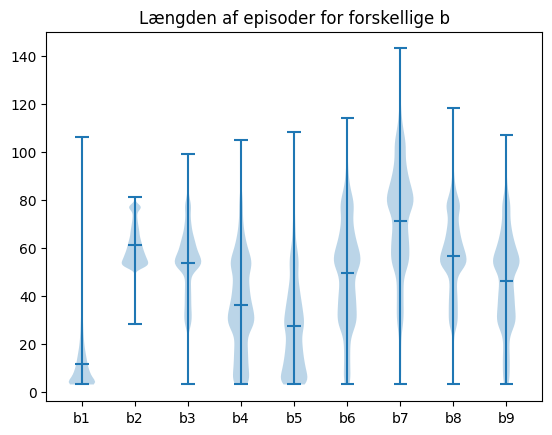

b1: Min:3.0, 0.25:4.0, Median: 8.0, Mean: 11.7059, 0.75:15.0, Max: 106.0, Var: 105.85420519
b2: Min:28.0, 0.25:55.0, Median: 59.0, Mean: 61.1574, 0.75:66.0, Max: 81.0, Var: 62.34462524
b3: Min:3.0, 0.25:46.0, Median: 55.0, Mean: 53.4381, 0.75:62.0, Max: 99.0, Var: 210.42676839
b4: Min:3.0, 0.25:21.0, Median: 35.0, Mean: 36.0996, 0.75:52.0, Max: 105.0, Var: 384.95007984
b5: Min:3.0, 0.25:11.0, Median: 25.0, Mean: 27.1838, 0.75:39.0, Max: 108.0, Var: 360.23641756
b6: Min:3.0, 0.25:33.0, Median: 52.0, Mean: 49.3014, 0.75:64.0, Max: 114.0, Var: 455.56155803999997
b7: Min:3.0, 0.25:56.0, Median: 76.0, Mean: 71.2666, 0.75:87.0, Max: 143.0, Var: 555.20232444
b8: Min:3.0, 0.25:47.0, Median: 57.0, Mean: 56.5654, 0.75:68.0, Max: 118.0, Var: 301.46212284
b9: Min:3.0, 0.25:31.0, Median: 49.0, Mean: 45.9852, 0.75:59.0, Max: 107.0, Var: 392.79878095999993


In [ ]:
printHistBox((3,3), resultsb, "Længden af episoder for forskellige b")

Testing whether there's a difference for the chosen b.

In [ ]:
resultb7 = {
    "b7,A=1": simLifespan(10000, 2, [1], defaultdict(lambda: [1]), [0, -1, 1], genWCol((3,4), 1), b7),
    "b7,A=-1": simLifespan(10000, 2, [-1], defaultdict(lambda: [-1]), [0, -1, 1], genWCol((3,4), 1), b7),
}

Starting lifespan simulation with ACTIONS: [1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten t

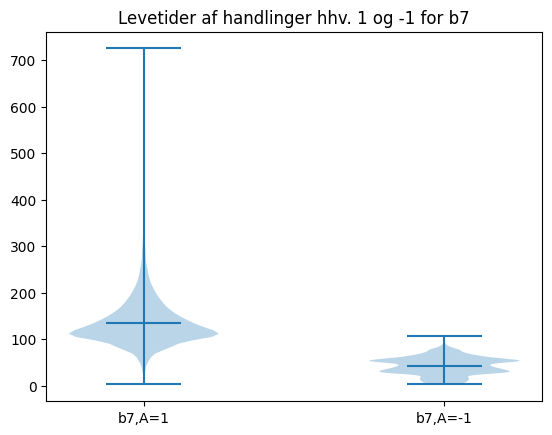

b7,A=1: Min:3.0, 0.25:106.0, Median: 124.0, Mean: 135.2621, 0.75:156.0, Max: 725.0, Var: 2414.6614035899997
b7,A=-1: Min:3.0, 0.25:30.0, Median: 44.0, Mean: 43.0626, 0.75:56.0, Max: 107.0, Var: 348.20108123999995


In [ ]:
printHistBox((2,1), resultb7, "Levetider af handlinger hhv. 1 og -1 for b7")

In [ ]:
resultswr = {
    "w1": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWRow((3,4), np.array([0,-0,0])), b7),
    "w2": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWRow((3,4), np.array([0,-1,1])), b7),
    "w3": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWRow((3,4), np.array([0,-5,5])), b7),
    'w4': simLifespan(10000, 2, [0, -1, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWRow((3,4), np.array([1,-1,1])), b7).
    "w5": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWRow((3,4), np.array([0,-5,1])), b7),
    "w6": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWRow((3,4), np.array([0,-1,5])), b7)
}

Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90

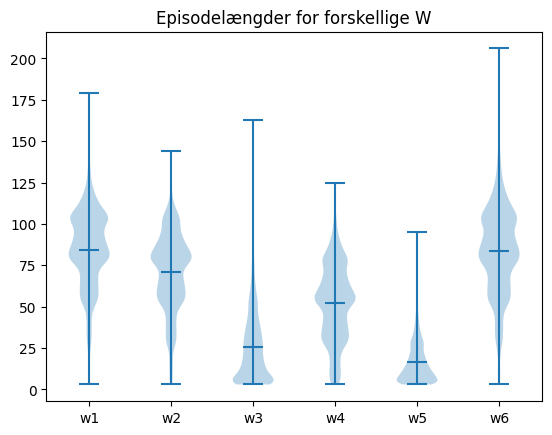

w1: Min:3.0, 0.25:70.0, Median: 86.0, Mean: 84.433, 0.75:102.0, Max: 179.0, Var: 580.812311
w2: Min:3.0, 0.25:56.0, Median: 75.0, Mean: 70.8212, 0.75:87.0, Max: 144.0, Var: 557.28483056
w3: Min:3.0, 0.25:8.0, Median: 20.0, Mean: 25.7727, 0.75:38.0, Max: 163.0, Var: 455.39763471
w4: Min:3.0, 0.25:35.0, Median: 54.0, Mean: 52.2072, 0.75:69.0, Max: 125.0, Var: 531.79326816
w5: Min:3.0, 0.25:7.0, Median: 13.0, Mean: 16.5737, 0.75:24.0, Max: 95.0, Var: 156.30256831
w6: Min:3.0, 0.25:65.0, Median: 84.0, Mean: 83.3511, 0.75:103.0, Max: 206.0, Var: 730.98962879


In [ ]:
printHistBox((2,3), resultswr, "Episodelængder for forskellige W")

In [ ]:
resultswc = {
    "w1": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWCol((3,4), np.array([1,1,0,0])), b7),
    "w2": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWCol((3,4), np.array([0,0,1,1])), b7),
    "w3": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWCol((3,4), np.array([1,0,0,1])), b7),
    "w4": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWCol((3,4), np.array([0,1,1,0])), b7),
    "w5": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWCol((3,4), np.array([8,4,2,1])), b7),
    "w6": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWCol((3,4), np.array([1,2,4,8])), b7)
}

Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90

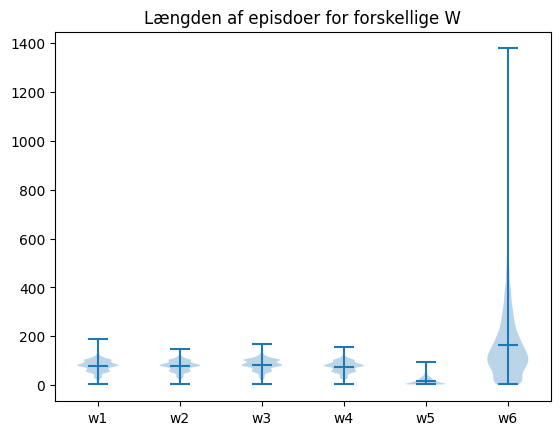

w1: Min:3.0, 0.25:61.75, Median: 80.0, Mean: 78.1167, 0.75:96.0, Max: 189.0, Var: 602.93108111
w2: Min:3.0, 0.25:61.0, Median: 80.0, Mean: 76.6486, 0.75:92.0, Max: 147.0, Var: 529.50091804
w3: Min:3.0, 0.25:68.0, Median: 85.0, Mean: 83.022, 0.75:102.0, Max: 169.0, Var: 583.282916
w4: Min:3.0, 0.25:59.0, Median: 78.0, Mean: 74.7033, 0.75:91.0, Max: 157.0, Var: 539.5980691100001
w5: Min:3.0, 0.25:6.0, Median: 13.0, Mean: 16.7493, 0.75:24.0, Max: 95.0, Var: 177.26264951
w6: Min:3.0, 0.25:74.0, Median: 132.0, Mean: 166.0384, 0.75:222.0, Max: 1378.0, Var: 19368.419925439997


In [ ]:
printHistBox((2,3), resultswc, "Længden af episdoer for forskellige W")

In [ ]:
w = genWCol((3,4), 1)

resultsH = {
    "H1": simLifespan(10000, 1, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], w, b7),
    "H2": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], w, b7),
    "H3": simLifespan(10000, 3, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], w, b7),
    "H4": simLifespan(10000, 4, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], w, b7)
}

Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 1
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90

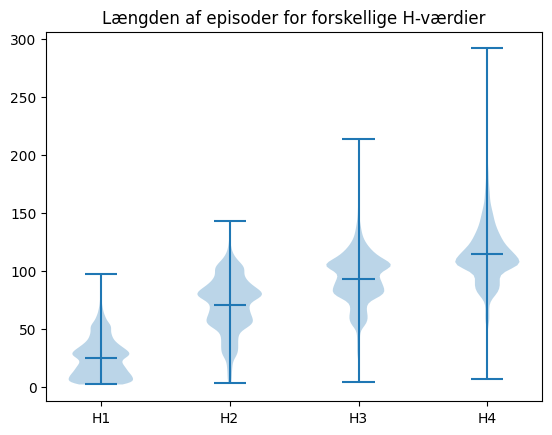

H1: Min:2.0, 0.25:10.0, Median: 23.0, Mean: 24.8138, 0.75:35.0, Max: 97.0, Var: 281.25532956
H2: Min:3.0, 0.25:55.0, Median: 74.0, Mean: 70.8544, 0.75:87.0, Max: 143.0, Var: 561.23940064
H3: Min:4.0, 0.25:80.0, Median: 95.0, Mean: 93.2906, 0.75:108.0, Max: 214.0, Var: 481.09755164
H4: Min:7.0, 0.25:101.0, Median: 111.0, Mean: 114.5089, 0.75:126.0, Max: 292.0, Var: 697.52052079


In [ ]:
printHistBox((2,2), resultsH, "Længden af episoder for forskellige H-værdier")

In [ ]:
resultDL = {
    "DL1": simLifespan(10000, 3, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWCol((3,4), 1), b7, negRatio=1),
    "DL0.75": simLifespan(10000, 3, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWCol((3,4), 1), b7, negRatio=0.75),
    "DL0.5": simLifespan(10000, 3, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWCol((3,4), 1), b7, negRatio=0.5)
}

Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 3
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 3
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90

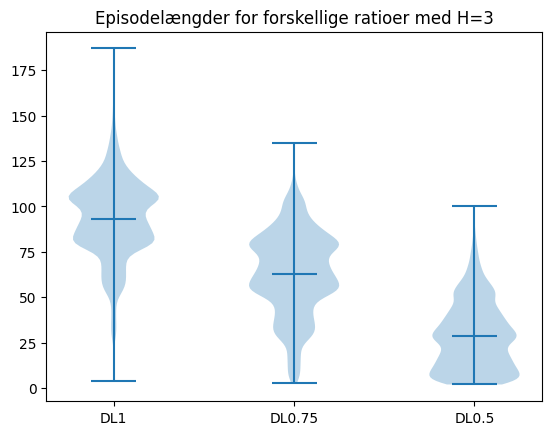

DL1: Min:4.0, 0.25:80.0, Median: 94.0, Mean: 92.9306, 0.75:107.0, Max: 187.0, Var: 499.30958364
DL0.75: Min:3.0, 0.25:50.0, Median: 64.0, Mean: 62.9706, 0.75:80.0, Max: 135.0, Var: 525.5019356399999
DL0.5: Min:2.0, 0.25:13.0, Median: 27.0, Mean: 28.6704, 0.75:41.0, Max: 100.0, Var: 350.57276384000005


In [ ]:
printHistBox((2,2),resultDL, "Episodelængder for forskellige ratioer med H=3")

In [ ]:
resultTemp = {
    "T1": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWCol((3,4), 1), b7, temp=1),
    "T0.5": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWCol((3,4), 1), b7, temp=0.5),
    "T0.3": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWCol((3,4), 1), b7, temp=0.3),
    "T0.1": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3, 1/3, 1/3]), [0, -1, 1], genWCol((3,4), 1), b7, temp=0.1)
}

Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90

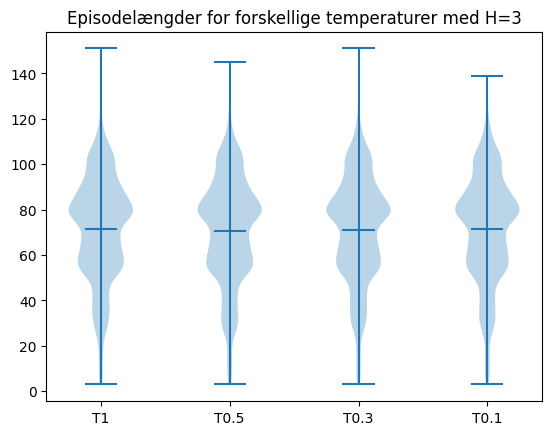

T1: Min:3.0, 0.25:56.0, Median: 76.0, Mean: 71.4218, 0.75:87.0, Max: 151.0, Var: 536.9580847599999
T0.5: Min:3.0, 0.25:56.0, Median: 75.0, Mean: 70.8051, 0.75:87.0, Max: 145.0, Var: 555.47871399
T0.3: Min:3.0, 0.25:56.0, Median: 75.0, Mean: 71.2215, 0.75:87.0, Max: 151.0, Var: 542.2378377499999
T0.1: Min:3.0, 0.25:56.0, Median: 76.0, Mean: 71.4897, 0.75:87.0, Max: 139.0, Var: 557.14089391


In [ ]:
printHistBox((2,2),resultTemp, "Episodelængder for forskellige temperaturer med H=3")

# Control/optimisation

In [ ]:
resultBaseline = {
    "Baseline": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3] * 3), [0, -1, 1], genWCol((3,4), 1), b7),
    "Forsinket": simLifespan(10000, 2, [-1, 0, 1, GL], defaultdict(lambda: [1/4] * 4), [0, -1, 1], genWCol((3,4), 1), b7),
    "Kryds": simLifespan(10000, 2, [-1, 0, 1], defaultdict(lambda: [1/3] * 3), [0, -1, 1], genWCol((3,6), 1), b7, cross = True)
}

Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1, 0, 1, 99], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten throug

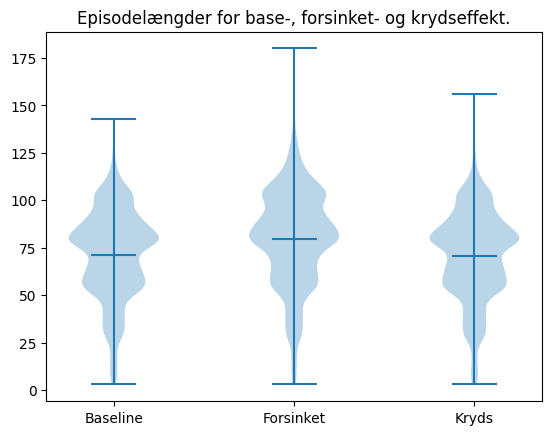

Baseline: Min:3.0, 0.25:56.0, Median: 76.0, Mean: 71.2977, 0.75:87.0, Max: 143.0, Var: 557.1778747100001
Forsinket: Min:3.0, 0.25:63.0, Median: 82.0, Mean: 79.8272, 0.75:98.25, Max: 180.0, Var: 646.35454016
Kryds: Min:3.0, 0.25:55.0, Median: 74.0, Mean: 70.4763, 0.75:86.0, Max: 156.0, Var: 546.37263831


In [ ]:
printHistBox((2,2),resultBaseline, "Episodelængder for base-, forsinket- og krydseffekt.")

In [ ]:
resultES = {
    "Baseline": FirstVisitMCControlES(10000, 2, [-1, 0, 1], [0, -1, 1], genWCol((3,4), 1), b7),
    "Forsinket": FirstVisitMCControlES(10000, 2, [-1, 0, 1, GL], [0, -1, 1], genWCol((3,4), 1), b7),
    "Kryds": FirstVisitMCControlES(10000, 2, [-1, 0, 1], [0, -1, 1], genWCol((3,6), 1), b7, cross = True)
}

Starting First Visit Value Exploring Starts Estimation. ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1], MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting First Visit Value Exploring Starts Estimation. ACTIONS: [-1, 0, 1, 99], EVENTS: [0, -1, 1], MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.0

In [ ]:
numStates = (3*3*3*3*5)*3
numStatesGL = (4*4*3*3*5)*4
print(f"{sum(resultES["Baseline"]["n"].values())/numStates}")
print((sum(resultES["Forsinket"]["n"].values())/numStatesGL))
print((sum(resultES["Kryds"]["n"].values())/numStates))
print(f"{len(resultES["Baseline"]["n"].values())}/{numStates}={len(resultES['Baseline']["n"].values())/numStates:.2f}")
print(f"{len(resultES["Forsinket"]["n"].values())}/{numStatesGL}={len(resultES['Forsinket']["n"].values())/numStatesGL:.2f}")
print(f"{len(resultES["Kryds"]["n"].values())}/{numStates}={len(resultES['Kryds']["n"].values())/numStates:.2f}")

[  2.85679012 135.91111111   3.31769547]
[ 0.98854167 59.24409722  1.0625      0.996875  ]
[  3.24526749 138.91604938   3.37283951]
360/1215=0.30
640/2880=0.22
360/1215=0.30


In [ ]:
inspect_q_values_zero_baseline(resultES["Baseline"], [-1, 0, 1])
inspectStarPolicy([-1,0,1], resultES["Baseline"])

State                          | Q-1            | Q0             | Q1             | Winner
----------------------------------------------------------------------------------
(np.int64(0), np.int64(0), np.int64(-1), np.int64(0), np.int64(3)) | 56.2857        | 40.3836        | 40.5833        | -1
(np.int64(0), np.int64(0), np.int64(0), np.int64(-1), np.int64(3)) | 46.3636        | 34.6835        | 42.6957        | -1
(np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(3)) | 54.1250        | 41.4058        | 53.9583        | -1
(np.int64(0), np.int64(0), np.int64(-1), np.int64(0), np.int64(2)) | 71.5556        | 65.6361        | 44.8000        | -1
(np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(2)) | 79.2222        | 66.6480        | 52.4545        | -1
(np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(2)) | 64.1429        | 71.1288        | 66.2857        | 0
(np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(4)) | 27.1875        | 25.2633

In [ ]:
inspectForsinket([-1, 0, 1, GL], resultES["Forsinket"])

State                          | Best Action  | Q-1            | Q0             | Q1             | Q_GL          
--------------------------------------------------------------------------------------------------
(1,99,0,0,5)    |           99 | 13.00          | 17.86          | 9.50           | 34.60         
(99,0,-1,1,5)   |           99 | 13.57          | 16.76          | 15.25          | 48.25         
(0,99,0,1,3)    |           -1 | 71.00          | 45.50          | 59.67          | 44.33         
(99,-1,1,1,3)   |           99 | 52.50          | 46.26          | 17.00          | 74.50         
(99,0,0,1,2)    |           99 | 57.00          | 72.12          | 94.67          | 119.50        
(0,99,-1,0,2)   |           99 | 95.83          | 75.58          | 82.75          | 99.00         
(99,0,-1,1,4)   |            1 | 16.00          | 22.46          | 31.86          | 24.50         
(99,-1,1,0,1)   |           -1 | 102.43         | 99.60          | 74.67          | 81.50     

In [ ]:
inspectStarPolicy([-1,0,1], resultES["Kryds"])

State           | Best Action  | Q-1            | Q+0            | Q+1           
----------------------------------------
(1,1,1,1,1)     |           -1 | 115.59         | 102.55        
(0,0,0,0,0)     |            0 | 0.00           | 0.00          
(0,0,0,-1,4)    |           -1 | 22.57          | 17.59         
(0,0,0,1,4)     |           -1 | 30.17          | 25.44         
(0,0,-1,0,4)    |            0 | 22.17          | 22.75         
(0,0,-1,1,4)    |            0 | 18.50          | 25.48         
(0,0,0,0,3)     |           -1 | 46.50          | 41.73         
(0,0,0,1,3)     |            0 | 40.38          | 42.81         
(0,0,1,0,2)     |            0 | 54.50          | 67.51         
(0,0,0,0,1)     |           -1 | 120.91         | 94.39         
(0,0,1,0,1)     |           -1 | 109.27         | 94.73         
(0,0,-1,0,1)    |           -1 | 119.20         | 95.36         
(-1,0,0,0,1)    |           -1 | 119.22         | 101.18        
(1,-1,1,0,1)    |            0 |

In [ ]:
resultPolicyES = {
    "Baseline": simLifespan(10000, 2, [-1, 0, 1], resultES["Baseline"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b=b7),
    "Forsinket": simLifespan(10000, 2, [-1, 0, 1, "gl"], resultES["Forsinket"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b=b7),
    "Kryds": simLifespan(10000, 2, [-1, 0, 1], resultES["Kryds"]["Policy"], [0, -1, 1], genWCol((3,6), 1), b=b7, cross=True)
}

Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1, 0, 1, 'gl'], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten thro

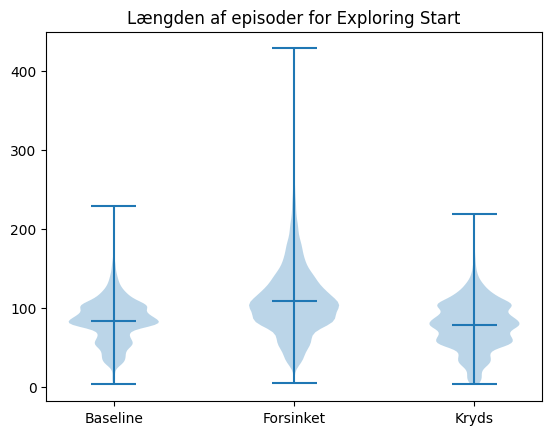

Baseline: Min:3.0, 0.25:66.0, Median: 85.0, Mean: 83.6408, 0.75:102.0, Max: 229.0, Var: 764.73117536
Forsinket: Min:5.0, 0.25:82.0, Median: 103.0, Mean: 108.9745, 0.75:130.0, Max: 428.0, Var: 1936.72604975
Kryds: Min:3.0, 0.25:57.0, Median: 78.0, Mean: 77.6231, 0.75:101.0, Max: 219.0, Var: 929.70944639


In [ ]:
printHistBox((2,2),resultPolicyES, "Længden af episoder for Exploring Start", includeBoxPlot=True)

In [ ]:
E = [0.3, 0.1, 0.01, 0.001]

resultEpsilon = {
    "e=0.3": OnPolicyEpsilonSoft(10000, 2, [-1, 0, 1], [0, -1, 1], E[0], genWCol((3,4), 1), b7),
    "e=0.1": OnPolicyEpsilonSoft(10000, 2, [-1, 0, 1], [0, -1, 1], E[1], genWCol((3,4), 1), b7),
    "e=0.01": OnPolicyEpsilonSoft(10000, 2, [-1, 0, 1], [0, -1, 1], E[2], genWCol((3,4), 1), b7),
    "e=0.001": OnPolicyEpsilonSoft(10000, 2, [-1, 0, 1], [0, -1, 1], E[3], genWCol((3,4), 1), b7),
}

Starting First Visit Value Estimation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting First Visit Value Estimation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%

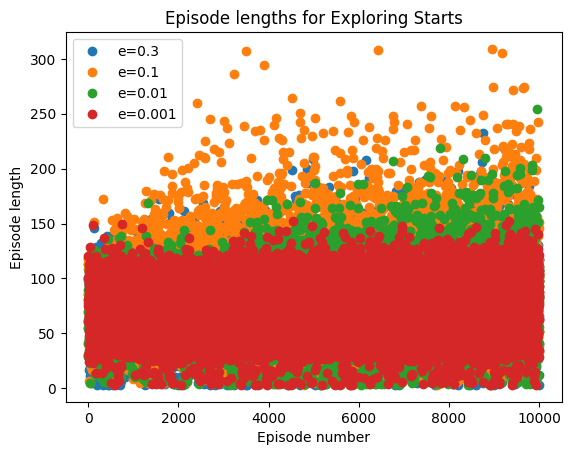

In [ ]:
for key, value in resultEpsilon.items():
    plt.plot(range(0, len(value["Lengths"])), value["Lengths"], 'o', label=key)
plt.legend()
plt.xlabel("Episode number")
plt.ylabel("Episode length")
plt.title("Episode lengths for Exploring Starts")
plt.show()

In [ ]:
numStates = (3*3*3*3*5)
numStatesGL = (4*4*3*3*5)
print(f"{sum(resultEpsilon["e=0.3"]["n"].values())/(numStates*3)}")
print((sum(resultEpsilon["e=0.1"]["n"].values())/(numStatesGL*4)))
print((sum(resultEpsilon["e=0.01"]["n"].values())/(numStates*3)))
print((sum(resultEpsilon["e=0.001"]["n"].values())/(numStates*3)))
print(f"{len(resultEpsilon["e=0.3"]["n"].values())}/{numStates}={len(resultEpsilon['e=0.3']["n"].values())/numStates:.2f}")
print(f"{len(resultEpsilon["e=0.1"]["n"].values())}/{numStatesGL}={len(resultEpsilon['e=0.1']["n"].values())/numStatesGL:.2f}")
print(f"{len(resultEpsilon["e=0.01"]["n"].values())}/{numStates}={len(resultEpsilon['e=0.01']["n"].values())/numStates:.2f}")
print(f"{len(resultEpsilon["e=0.001"]["n"].values())}/{numStates}={len(resultEpsilon['e=0.001']["n"].values())/numStates:.2f}")

[123.16460905 102.57037037 226.16954733]
[41.71388889 53.76805556 88.41006944]
[130.07407407 101.31934156 176.01152263]
[128.45761317 107.82139918 138.14485597]
360/405=0.89
360/720=0.50
358/405=0.88
354/405=0.87


In [ ]:
inspect_q_values_zero_baseline(resultEpsilon["e=0.3"], [-1, 0, 1])
inspectStarPolicy([-1,0,1], resultEpsilon["e=0.3"])

State                          | Q-1            | Q0             | Q1             | Winner
----------------------------------------------------------------------------------
(np.int64(-1), np.int64(0), np.int64(0), np.int64(0), np.int64(3)) | 37.4298        | 34.6441        | 35.4937        | -1
(np.int64(-1), np.int64(1), np.int64(-1), np.int64(0), np.int64(3)) | 35.9478        | 37.7598        | 35.7869        | 0
(np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(3)) | 37.3846        | 35.6803        | 35.1285        | -1
(np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(3)) | 36.1997        | 39.3532        | 37.7909        | 0
(np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(3)) | 34.9130        | 36.8356        | 36.1543        | 0
(np.int64(-1), np.int64(1), np.int64(0), np.int64(0), np.int64(2)) | 58.8846        | 57.2996        | 54.9083        | -1
(np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(2)) | 56.1894        | 53.2928 

In [ ]:
inspect_q_values_zero_baseline(resultEpsilon["e=0.1"], [-1, 0, 1])
inspectStarPolicy([-1,0,1], resultEpsilon["e=0.1"])

State                          | Q-1            | Q0             | Q1             | Winner
----------------------------------------------------------------------------------
(np.int64(-1), np.int64(-1), np.int64(1), np.int64(-1), np.int64(5)) | 12.0000        | 15.0333        | 0.0000         | 0
(np.int64(1), np.int64(-1), np.int64(0), np.int64(1), np.int64(5)) | 12.1111        | 26.1281        | 7.2000         | 0
(np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(5)) | 14.1667        | 25.5097        | 14.9344        | 0
(np.int64(0), np.int64(-1), np.int64(1), np.int64(1), np.int64(5)) | 0.0000         | 12.6667        | 4.0000         | 0
(np.int64(0), np.int64(1), np.int64(-1), np.int64(0), np.int64(4)) | 30.9262        | 29.3030        | 22.9626        | -1
(np.int64(-1), np.int64(1), np.int64(0), np.int64(0), np.int64(4)) | 32.4377        | 22.1214        | 31.8430        | -1
(np.int64(1), np.int64(-1), np.int64(0), np.int64(0), np.int64(4)) | 27.4793        | 33.44

In [ ]:
inspect_q_values_zero_baseline(resultEpsilon["e=0.01"], [-1, 0, 1])
inspectStarPolicy([-1,0,1], resultEpsilon["e=0.01"])

State                          | Q-1            | Q0             | Q1             | Winner
----------------------------------------------------------------------------------
(np.int64(0), np.int64(-1), np.int64(0), np.int64(-1), np.int64(3)) | 1.0000         | 26.4013        | 0.0000         | 0
(np.int64(0), np.int64(0), np.int64(-1), np.int64(0), np.int64(3)) | 26.0573        | 0.0000         | 0.0000         | -1
(np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(3)) | 30.7445        | 25.0000        | 25.8750        | -1
(np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(3)) | 41.5164        | 42.3261        | 39.2553        | 0
(np.int64(-1), np.int64(1), np.int64(0), np.int64(0), np.int64(3)) | 40.0698        | 43.4239        | 42.6849        | 0
(np.int64(-1), np.int64(-1), np.int64(0), np.int64(0), np.int64(3)) | 22.6250        | 37.4925        | 32.0709        | 0
(np.int64(0), np.int64(1), np.int64(0), np.int64(-1), np.int64(3)) | 3.0000         | 35.836

In [ ]:
inspect_q_values_zero_baseline(resultEpsilon["e=0.001"], [-1, 0, 1])
inspectStarPolicy([-1,0,1], resultEpsilon["e=0.001"])

State                          | Q-1            | Q0             | Q1             | Winner
----------------------------------------------------------------------------------
(np.int64(-1), np.int64(-1), np.int64(0), np.int64(-1), np.int64(4)) | 1.0000         | 11.3628        | 0.0000         | 0
(np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(4)) | 18.2305        | 0.0000         | 0.0000         | -1
(np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(4)) | 18.9056        | 0.0000         | 15.0937        | -1
(np.int64(1), np.int64(-1), np.int64(0), np.int64(0), np.int64(4)) | 18.3610        | 9.6667         | 0.0000         | -1
(np.int64(1), np.int64(-1), np.int64(1), np.int64(0), np.int64(4)) | 16.6294        | 9.0000         | 0.0000         | -1
(np.int64(1), np.int64(0), np.int64(-1), np.int64(0), np.int64(4)) | 17.8497        | 0.0000         | 0.0000         | -1
(np.int64(0), np.int64(1), np.int64(1), np.int64(-1), np.int64(4)) | 0.0000         | 16.

In [ ]:
resultPolicyEpsilon = {
    "e=0.3": simLifespan(10000, 2, [-1, 0, 1], resultEpsilon["e=0.3"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
    "e=0.1": simLifespan(10000, 2, [-1, 0, 1], resultEpsilon["e=0.1"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
    "e=0.01": simLifespan(10000, 2, [-1, 0, 1], resultEpsilon["e=0.01"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
    "e=0.001": simLifespan(10000, 2, [-1, 0, 1], resultEpsilon["e=0.001"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7)
}

Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90

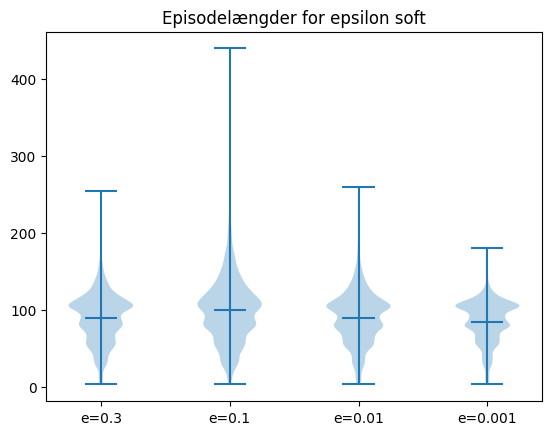

e=0.3: Min:3.0, 0.25:68.0, Median: 93.0, Mean: 89.594, 0.75:110.0, Max: 254.0, Var: 1031.2207640000001
e=0.1: Min:3.0, 0.25:74.0, Median: 101.0, Mean: 99.7267, 0.75:122.0, Max: 440.0, Var: 1739.10320711
e=0.01: Min:3.0, 0.25:68.0, Median: 92.0, Mean: 90.0703, 0.75:111.0, Max: 260.0, Var: 1127.0909579100003
e=0.001: Min:3.0, 0.25:68.0, Median: 89.0, Mean: 84.7539, 0.75:105.0, Max: 181.0, Var: 726.05673479


In [ ]:
printHistBox((2,2), resultPolicyEpsilon, "Episodelængder for epsilon soft")

In [ ]:
EPSILON2 = 0.1
resultSoft = {
    "Baseline": OnPolicyEpsilonSoft(10000, 2, [-1, 0, 1], [0, -1, 1], EPSILON2, genWCol((3,4), 1), b7),
    "Forsinket": OnPolicyEpsilonSoft(10000, 2, [-1, 0, 1, GL], [0, -1, 1], EPSILON2, genWCol((3,4), 1), b7),
    "Kryds": OnPolicyEpsilonSoft(10000, 2, [-1, 0, 1], [0, -1, 1], EPSILON2, genWCol((3,6), 1), b7, cross = True)
}

Starting First Visit Value Estimation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting First Visit Value Estimation with ACTIONS: [-1, 0, 1, 99], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85

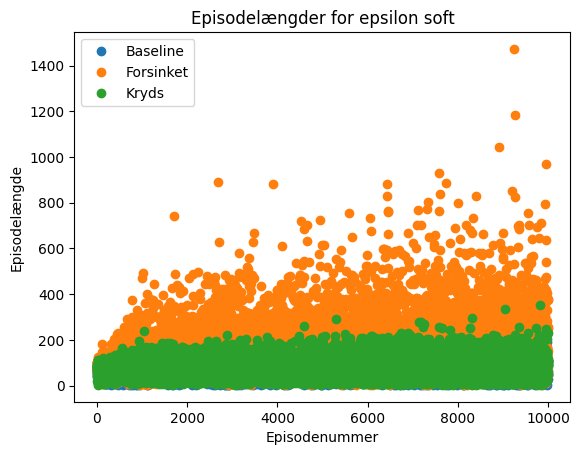

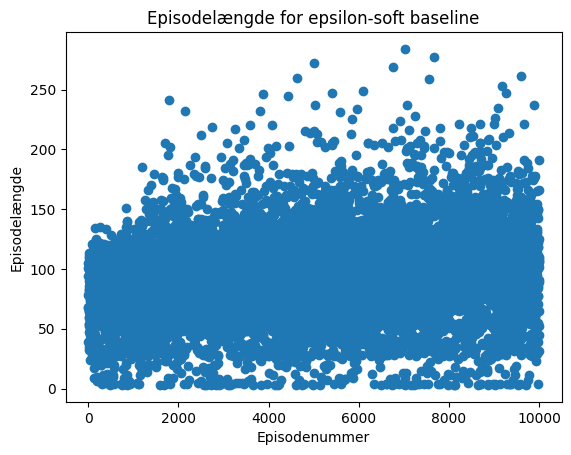

In [ ]:
for key, value in resultSoft.items():
    plt.plot(range(0, len(value["Lengths"])), value["Lengths"], 'o', label=key)
plt.legend()
plt.xlabel("Episodenummer")
plt.ylabel("Episodelængde")
plt.title("Episodelængder for epsilon soft")
plt.show()
plt.plot(range(0, len(resultSoft["Baseline"]["Lengths"])), resultSoft["Baseline"]["Lengths"], 'o', label=key)
plt.xlabel("Episodenummer")
plt.ylabel("Episodelængde")
plt.title("Episodelængde for epsilon-soft baseline")
plt.show()

In [ ]:
numStates = (3*3*3*3*5)*3
numStatesGL = (4*4*3*3*5)*4
print(sum(resultSoft["Baseline"]["n"].values())/numStates)
print((sum(resultSoft["Forsinket"]["n"].values())/numStatesGL))
print((sum(resultSoft["Kryds"]["n"].values())/numStates))
print(f"{len(resultSoft["Baseline"]["n"].values())}/{numStates}={len(resultSoft["Baseline"]["n"].values())/numStates:.2f}")
print(f"{len(resultSoft["Forsinket"]["n"].values())}/{numStatesGL}={len(resultSoft["Forsinket"]["n"].values())/numStatesGL:.2f}")
print(f"{len(resultSoft["Kryds"]["n"].values())}/{numStates}={len(resultSoft["Kryds"]["n"].values())/numStates:.2f}")

[105.618107   151.41563786 226.27242798]
[52.80451389 93.56284722 71.97951389 84.16423611]
[115.03539095  88.8872428  197.12757202]
360/1215=0.30
617/2880=0.21
359/1215=0.30


In [ ]:
inspect_q_values_zero_baseline(resultSoft["Baseline"], [-1, 0, 1])
inspectStarPolicy([-1,0,1], resultSoft["Baseline"])

State                          | Q-1            | Q0             | Q1             | Winner
----------------------------------------------------------------------------------
(np.int64(1), np.int64(-1), np.int64(1), np.int64(0), np.int64(3)) | 49.2153        | 43.3346        | 41.0565        | -1
(np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(3)) | 42.7083        | 46.5181        | 42.6005        | 0
(np.int64(-1), np.int64(1), np.int64(0), np.int64(0), np.int64(3)) | 35.4301        | 45.1785        | 42.2854        | 0
(np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(3)) | 37.2685        | 49.1507        | 47.6567        | 0
(np.int64(-1), np.int64(1), np.int64(0), np.int64(1), np.int64(3)) | 43.4725        | 45.1462        | 33.1014        | 0
(np.int64(0), np.int64(-1), np.int64(0), np.int64(0), np.int64(3)) | 42.5081        | 40.7838        | 32.6886        | -1
(np.int64(0), np.int64(1), np.int64(-1), np.int64(0), np.int64(2)) | 60.1257        | 45.2857 

In [ ]:
inspectForsinket([-1, 0, 1, GL], resultSoft["Forsinket"])

State                          | Best Action  | Q-1            | Q0             | Q1             | Q_GL          
--------------------------------------------------------------------------------------------------
(0,99,0,0,1)    |        0.925 | 158.08         | 125.62         | 124.69         | 126.27        
(99,0,0,0,1)    |        0.025 | 96.53          | 98.80          | 133.70         | 169.67        
(-1,99,0,1,1)   |        0.025 | 145.37         | 169.73         | 119.94         | 118.32        
(99,1,1,1,1)    |        0.025 | 112.78         | 96.11          | 141.35         | 156.41        
(1,99,0,0,1)    |        0.025 | 92.27          | 130.89         | 126.63         | 139.07        
(99,-1,0,1,1)   |        0.925 | 141.38         | 125.85         | 102.12         | 124.25        
(-1,99,0,0,2)   |        0.925 | 136.87         | 111.01         | 108.35         | 79.64         
(99,-1,0,1,2)   |        0.025 | 87.29          | 92.54          | 122.38         | 125.99    

In [ ]:
inspectStarPolicy([-1,0,1], resultSoft["Kryds"])

State           | Best Action  | Q-1            | Q+0            | Q+1           
----------------------------------------
(0,0,0,0,1)     | 0.03333333333333333 | 80.71          | 79.74         
(0,-1,0,0,1)    | 0.03333333333333333 | 74.24          | 72.79         
(-1,-1,0,0,1)   | 0.9333333333333333 | 82.03          | 73.59         
(-1,1,0,0,1)    | 0.9333333333333333 | 76.62          | 71.50         
(1,-1,0,0,1)    | 0.9333333333333333 | 78.11          | 74.85         
(-1,-1,0,-1,1)  | 0.9333333333333333 | 73.90          | 67.22         
(-1,0,-1,0,1)   | 0.03333333333333333 | 71.16          | 72.06         
(0,1,0,-1,1)    | 0.03333333333333333 | 71.75          | 66.29         
(1,0,-1,0,1)    | 0.9333333333333333 | 76.90          | 74.21         
(0,1,0,0,1)     | 0.9333333333333333 | 86.08          | 81.43         
(1,0,0,0,1)     | 0.03333333333333333 | 73.32          | 75.90         
(-1,0,0,-1,1)   | 0.03333333333333333 | 70.25          | 75.34         
(1,-1,0,-1,1)   | 0

In [ ]:
resultSoftPolicy = {
    "Baseline": simLifespan(10000, 2, [-1, 0, 1], resultSoft["Baseline"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
    "Forsinket": simLifespan(10000, 2, [-1, 0, 1, GL], resultSoft["Forsinket"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
    "Kryds": simLifespan(10000, 2, [-1, 0, 1], resultSoft["Kryds"]["Policy"], [0, -1, 1], genWCol((3,6), 1), b7, cross = True)
}

Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1, 0, 1, 99], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten throug

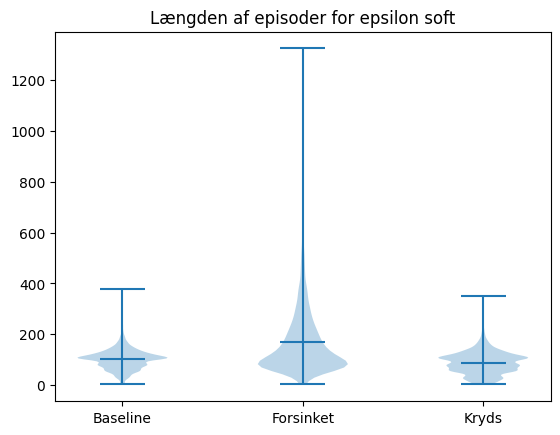

Baseline: Min:3.0, 0.25:77.0, Median: 105.0, Mean: 101.7021, 0.75:123.0, Max: 378.0, Var: 1511.6631555899999
Forsinket: Min:3.0, 0.25:81.0, Median: 126.0, Mean: 170.2845, 0.75:217.0, Max: 1323.0, Var: 17376.75415975
Kryds: Min:3.0, 0.25:58.0, Median: 88.0, Mean: 88.4851, 0.75:115.0, Max: 349.0, Var: 1862.28397799


In [ ]:
printHistBox((2,2), resultSoftPolicy, "Længden af episoder for epsilon soft")

In [ ]:
resultOffPolicy = {
    "Baseline": OffPolicyMCControl(10000, 2, [-1, 0, 1], [0, -1, 1], genWCol((3,4), 1), b7),
    "Forsinket": OffPolicyMCControl(10000, 2, [-1, 0, 1, GL], [0, -1, 1], genWCol((3,4), 1), b7),
    "Kryds": OffPolicyMCControl(10000, 2, [-1, 0, 1], [0, -1, 1], genWCol((3,6), 1), b7, cross = True)
}

Starting Off Policy Control with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Starting Off Policy Control with ACTIONS: [-1, 0, 1, 99], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten thr

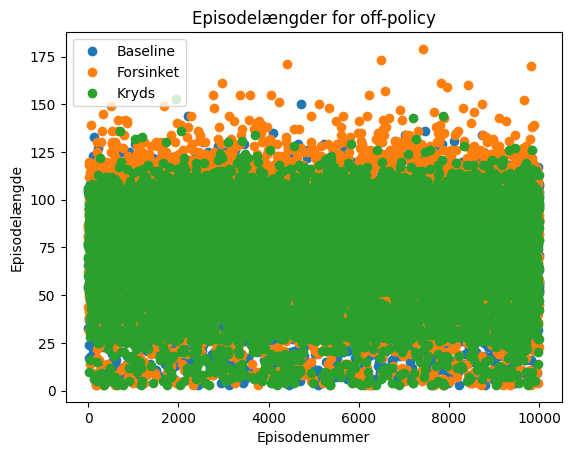

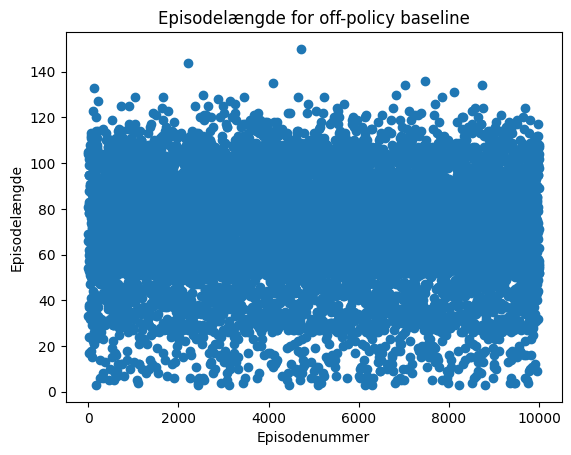

In [ ]:
for key, value in resultOffPolicy.items():
    plt.plot(range(0, len(value["Lengths"])), value["Lengths"], 'o', label=key)
plt.legend()
plt.xlabel("Episodenummer")
plt.ylabel("Episodelængde")
plt.title("Episodelængder for off-policy")
plt.show()
plt.plot(range(0, len(resultOffPolicy['Baseline']["Lengths"])), resultOffPolicy['Baseline']["Lengths"], 'o', label=key)
plt.xlabel("Episodenummer")
plt.ylabel("Episodelængde")
plt.title("Episodelængde for off-policy baseline")
plt.show()

In [ ]:
numStates = (3*3*3*3*5)*3
numStatesGL = (4*4*3*3*5)*4
print(f"{len(resultOffPolicy["Baseline"]["Q"].values())}/{numStates}={len(resultOffPolicy["Baseline"]["Q"].values())/numStates:.2f}")
print(f"{len(resultOffPolicy["Forsinket"]["Q"].values())}/{numStatesGL}={len(resultOffPolicy["Forsinket"]["Q"].values())/numStatesGL:.2f}")
print(f"{len(resultOffPolicy["Kryds"]["Q"].values())}/{numStates}={len(resultOffPolicy["Kryds"]["Q"].values())/numStates:.2f}")

316/1215=0.26
492/2880=0.17
313/1215=0.26


In [ ]:
inspect_q_values_zero_baseline(resultOffPolicy["Baseline"], [-1, 0, 1])
inspectStarPolicy([-1,0,1], resultOffPolicy["Baseline"])

State                          | Q-1            | Q0             | Q1             | Winner
----------------------------------------------------------------------------------
(np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(5)) | 3.4000         | 2.0000         | 0.0000         | -1
(np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(4)) | 2.7438         | 50.0000        | 37.0000        | 0
(np.int64(-1), np.int64(0), np.int64(0), np.int64(0), np.int64(4)) | 3.0299         | 51.0000        | 8.5716         | 0
(np.int64(0), np.int64(-1), np.int64(0), np.int64(0), np.int64(4)) | 34.0000        | 12.9747        | 5.1254         | -1
(np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(4)) | 35.0000        | 3.4444         | 4.6053         | -1
(np.int64(-1), np.int64(1), np.int64(0), np.int64(1), np.int64(4)) | 3.5517         | 9.9716         | 8.0000         | 0
(np.int64(0), np.int64(-1), np.int64(1), np.int64(0), np.int64(4)) | 47.0000        | 52.0000 

In [ ]:
inspectForsinket([-1, 0, 1, GL], resultOffPolicy["Forsinket"])

State                          | Best Action  | Q-1            | Q0             | Q1             | Q_GL          
--------------------------------------------------------------------------------------------------
(99,1,0,1,3)    |           99 | 4.11           | 4.56           | 4.55           | 7.98          
(99,99,0,0,3)   |           -1 | 46.00          | 4.52           | 6.95           | 32.00         
(-1,99,0,0,3)   |           99 | 3.00           | 4.88           | 5.00           | 33.00         
(1,99,0,0,2)    |           99 | 3.00           | 0.00           | 3.00           | 50.00         
(99,-1,0,1,2)   |           99 | 5.61           | 79.00          | 30.00          | 81.00         
(99,99,-1,0,2)  |           -1 | 31.00          | 0.00           | 0.00           | 0.00          
(-1,99,1,-1,2)  |           99 | 0.00           | 0.00           | 0.00           | 32.00         
(0,99,0,0,2)    |           99 | 54.00          | 3.00           | 4.00           | 76.98     

In [ ]:
inspectStarPolicy([-1,0,1], resultOffPolicy["Kryds"])

State           | Best Action  | Q-1            | Q+0            | Q+1           
----------------------------------------
(-1,-1,0,-1,3)  |            0 | 2.58           | 6.88          
(-1,0,0,0,3)    |            0 | 2.78           | 44.00         
(0,1,0,1,2)     |           -1 | 27.00          | 6.90          
(0,0,0,0,2)     |            0 | 2.62           | 62.00         
(1,0,0,0,2)     |            0 | 18.00          | 63.00         
(1,-1,0,0,2)    |           -1 | 77.95          | 3.99          
(-1,1,-1,0,2)   |           -1 | 12.00          | 2.00          
(0,0,-1,0,2)    |           -1 | 14.00          | 2.00          
(0,0,0,-1,2)    |            0 | 1.41           | 15.00         
(1,0,1,0,2)     |           -1 | 68.00          | 5.72          
(1,1,0,1,2)     |            0 | 2.00           | 69.00         
(-1,0,1,0,2)    |            0 | 2.75           | 29.00         
(-1,-1,0,1,1)   |            0 | 2.43           | 30.00         
(1,0,0,0,1)     |           -1 |

In [ ]:
resultOff = {
    "Baseline": simLifespan(10000, 2, [-1, 0, 1], resultOffPolicy["Baseline"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
    "Forsinket": simLifespan(10000, 2, [-1, 0, 1, GL], resultOffPolicy["Forsinket"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
    "Kryds": simLifespan(10000, 2, [-1, 0, 1], resultOffPolicy["Kryds"]["Policy"], [0, -1, 1], genWCol((3,6), 1), b7, cross = True)
}

Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1, 0, 1, 99], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten throug

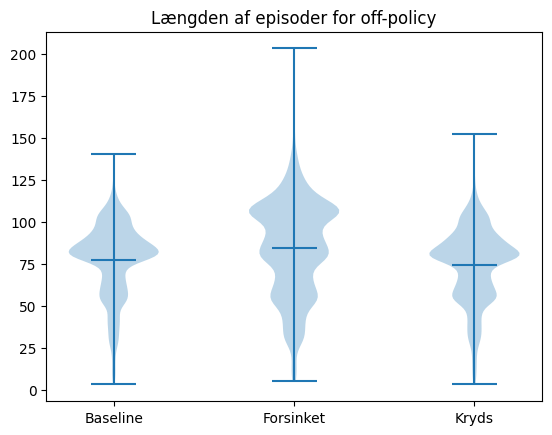

Baseline: Min:3.0, 0.25:64.0, Median: 81.0, Mean: 76.9574, 0.75:91.0, Max: 140.0, Var: 482.30398524000003
Forsinket: Min:5.0, 0.25:63.0, Median: 87.0, Mean: 84.1827, 0.75:106.0, Max: 203.0, Var: 812.01072071
Kryds: Min:3.0, 0.25:59.0, Median: 79.0, Mean: 73.8524, 0.75:88.0, Max: 152.0, Var: 492.94401424


In [ ]:
printHistBox((2,2), resultOff, "Længden af episoder for off-policy")

In [ ]:
resultNES = {
    "loops=1000": FirstVisitMCControlES(1000, 2, [-1, 0, 1], [0, -1, 1], genWCol((3,4), 1), b7),
    "loops=10000": FirstVisitMCControlES(10_000, 2, [-1, 0, 1], [0, -1, 1], genWCol((3,4), 1), b7),
    "loops=100000": FirstVisitMCControlES(100_000, 2, [-1, 0, 1], [0, -1, 1], genWCol((3,4), 1), b7),
}

Starting First Visit Value Exploring Starts Estimation. ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1], MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%


KeyboardInterrupt: 

In [ ]:
numStates = (3*3*3*3*5)*3
for key, value in resultNES.items():
    print(f"{sum(resultNES[key]["n"].values())/numStates}")
    print(f"{len(resultNES[key]["n"].values())}/{numStates}={len(resultNES[key]["n"].values())/numStates:.2f}")

[ 0.24444444 14.28477366  0.27654321]
351/1215=0.29
[  3.11358025 137.76378601   3.42386831]
360/1215=0.30
[  31.0962963  1360.27407407   38.22222222]
360/1215=0.30


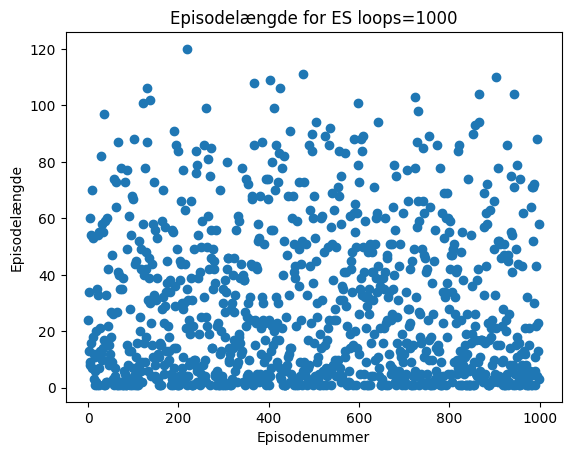

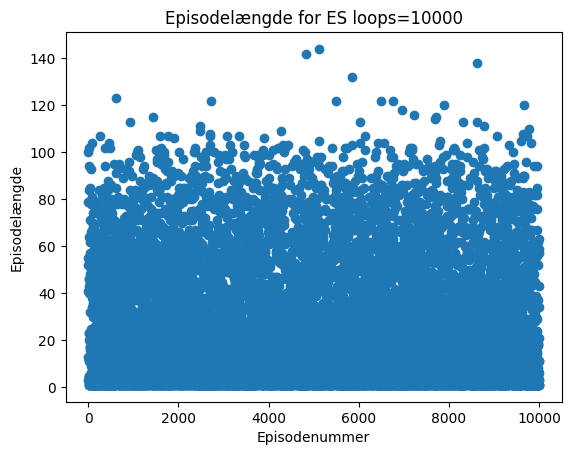

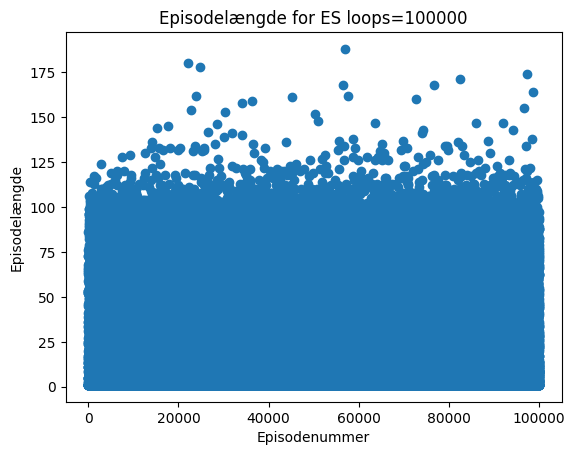

In [ ]:
for key, value in resultNES.items():
    plt.plot(range(0, len(resultNES[key]["Lengths"])), resultNES[key]["Lengths"], 'o', label=key)
    plt.xlabel("Episodenummer")
    plt.ylabel("Episodelængde")
    plt.title("Episodelængde for ES " + key)
    plt.show()

In [ ]:
resultNESPolicy = {
    "loops=1000": simLifespan(10000, 2, [-1, 0, 1], resultNES["loops=1000"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
    "loops=10000": simLifespan(10000, 2, [-1, 0, 1], resultNES["loops=10000"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
    "loops=100000": simLifespan(10000, 2, [-1, 0, 1], resultNES["loops=100000"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7)
}

Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90

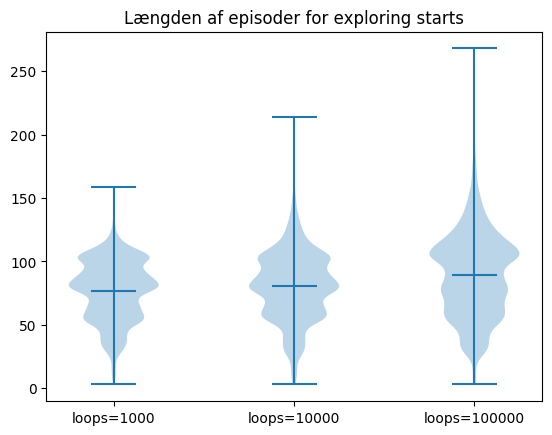

loops=1000: Min:3.0, 0.25:59.0, Median: 80.0, Mean: 76.7642, 0.75:95.0, Max: 159.0, Var: 579.56199836
loops=10000: Min:3.0, 0.25:61.0, Median: 81.0, Mean: 80.5225, 0.75:101.0, Max: 214.0, Var: 767.49069375
loops=100000: Min:3.0, 0.25:64.0, Median: 90.0, Mean: 89.4249, 0.75:112.0, Max: 268.0, Var: 1155.7469599899998


In [ ]:
printHistBox((2,2), resultNESPolicy, "Længden af episoder for exploring starts")

In [ ]:
resultNSoft = {
    "loops=1000": OnPolicyEpsilonSoft(1000, 2, [-1, 0, 1], [0, -1, 1], 0.1, genWCol((3,4), 1), b7),
    "loops=10000": OnPolicyEpsilonSoft(10_000, 2, [-1, 0, 1], [0, -1, 1], 0.1, genWCol((3,4), 1), b7),
    "loops=100000": OnPolicyEpsilonSoft(100_000, 2, [-1, 0, 1], [0, -1, 1], 0.1, genWCol((3,4), 1), b7),
}

Starting First Visit Value Estimation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting First Visit Value Estimation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%

In [ ]:
numStates = (3*3*3*3*5)*3
for key, value in resultNSoft.items():
    print(f"{sum(resultNSoft[key]["n"].values())/numStates}")
    print(f"{len(resultNSoft[key]["n"].values())}/{numStates}={len(resultNSoft[key]["n"].values())/numStates:.2f}")

[11.01646091 10.99835391 20.01152263]
355/1215=0.29
[106.6617284  125.79423868 242.0345679 ]
360/1215=0.30
[ 924.96049383  725.61152263 2592.62057613]
360/1215=0.30


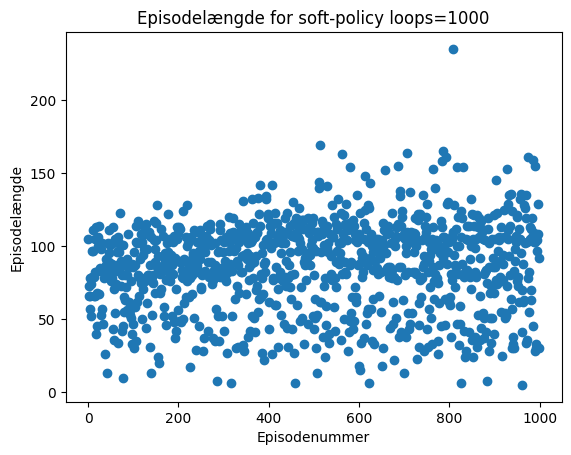

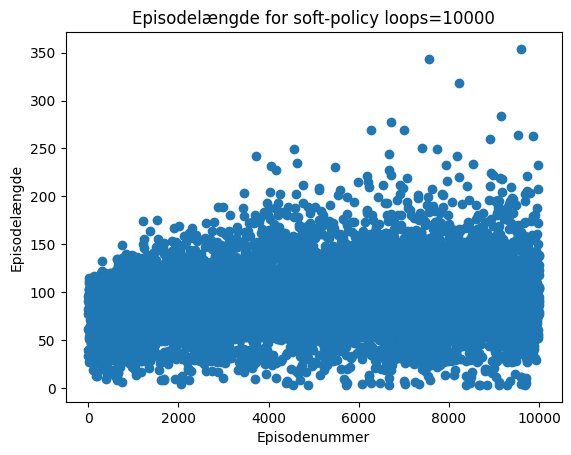

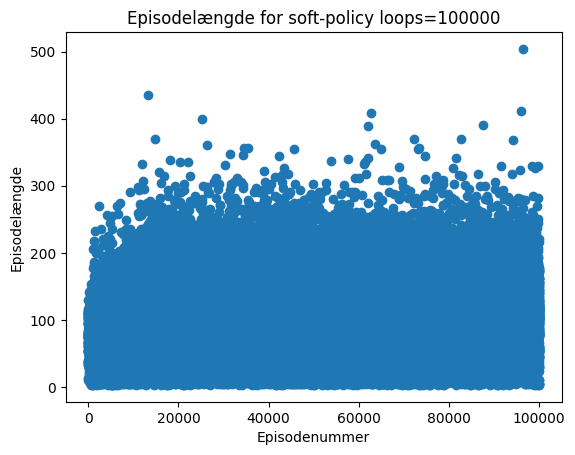

In [ ]:
for key, value in resultNSoft.items():
    plt.plot(range(0, len(resultNSoft[key]["Lengths"])), resultNSoft[key]["Lengths"], 'o', label=key)
    plt.xlabel("Episodenummer")
    plt.ylabel("Episodelængde")
    plt.title("Episodelængde for soft-policy " + key)
    plt.show()

In [ ]:
resultNSoftPolicy = {
    "loops=1000": simLifespan(10000, 2, [-1, 0, 1], resultNSoft["loops=1000"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
    "loops=10000": simLifespan(10_000, 2, [-1, 0, 1], resultNSoft["loops=10000"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
    "loops=100000": simLifespan(10_000, 2, [-1, 0, 1], resultNSoft["loops=100000"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
}

Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90

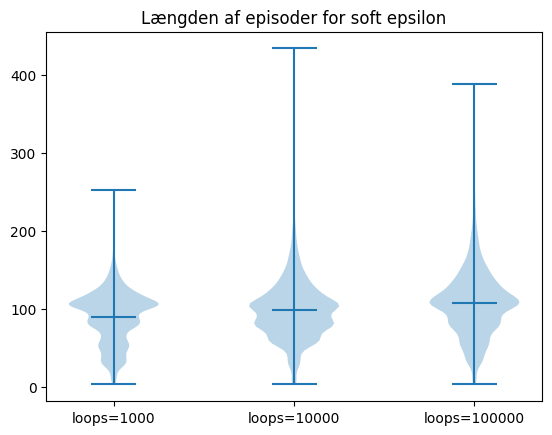

loops=1000: Min:3.0, 0.25:68.0, Median: 97.0, Mean: 89.9803, 0.75:112.0, Max: 253.0, Var: 1124.19151191
loops=10000: Min:3.0, 0.25:76.0, Median: 97.0, Mean: 98.206, 0.75:118.0, Max: 434.0, Var: 1412.701564
loops=100000: Min:3.0, 0.25:80.0, Median: 107.0, Mean: 107.073, 0.75:129.0, Max: 389.0, Var: 1741.262271


In [ ]:
printHistBox((2,2), resultNSoftPolicy, "Længden af episoder for soft epsilon", includeBoxPlot=False)

In [ ]:
resultNOff = {
    "loops=1000": OffPolicyMCControl(1000, 2, [-1, 0, 1], [0, -1, 1], genWCol((3,4), 1), b7),
    "loops=10000": OffPolicyMCControl(10_000, 2, [-1, 0, 1], [0, -1, 1], genWCol((3,4), 1), b7),
    "loops=100000": OffPolicyMCControl(100_000, 2, [-1, 0, 1], [0, -1, 1], genWCol((3,4), 1), b7),
}

Starting Off Policy Control with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Starting Off Policy Control with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through

In [ ]:
numStates = (3*3*3*3*5)*3
for key, value in resultNOff.items():
    print(f"{len(resultNOff[key]["Q"].values())}/{numStates}={len(resultNOff[key]["Q"].values())/numStates:.2f}")

248/1215=0.20
319/1215=0.26
353/1215=0.29


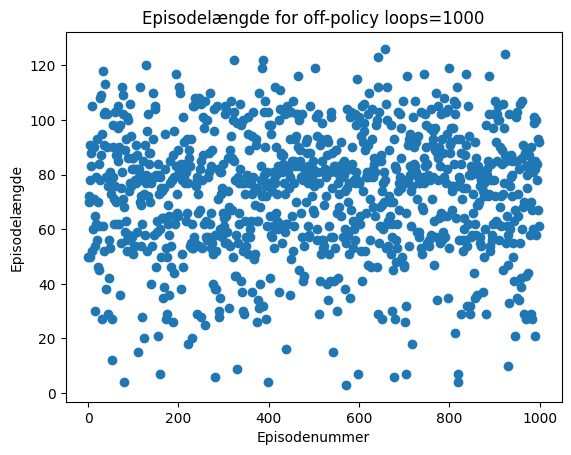

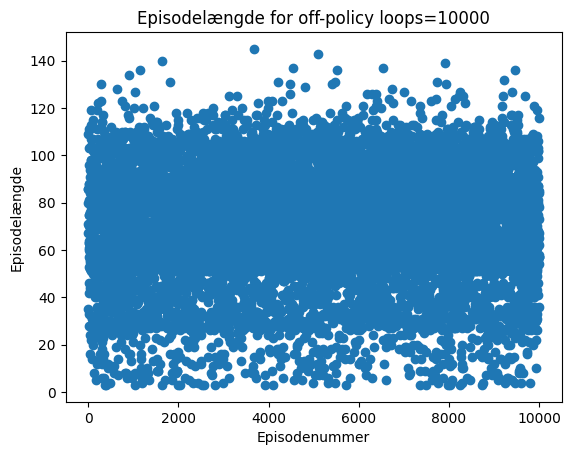

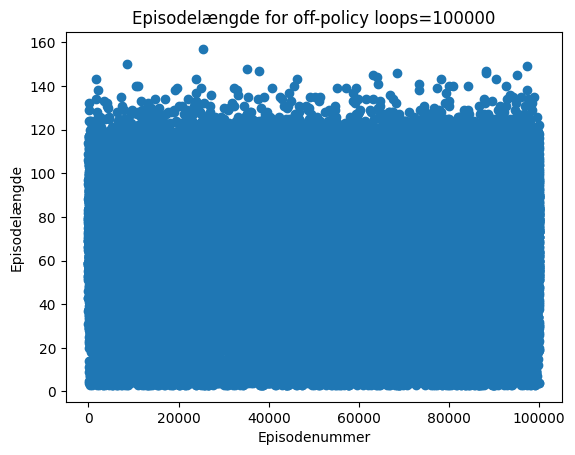

In [ ]:
for key, value in resultNOff.items():
    plt.plot(range(0, len(resultNOff[key]["Lengths"])), resultNOff[key]["Lengths"], 'o', label=key)
    plt.xlabel("Episodenummer")
    plt.ylabel("Episodelængde")
    plt.title("Episodelængde for off-policy " + key)
    plt.show()

In [ ]:
resultNOffPolicy = {
    "loops=1000": simLifespan(10000, 2, [-1, 0, 1], resultNOff["loops=1000"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
    "loops=10000": simLifespan(10_000, 2, [-1, 0, 1], resultNOff["loops=10000"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
    "loops=100000": simLifespan(10_000, 2, [-1, 0, 1], resultNOff["loops=100000"]["Policy"], [0, -1, 1], genWCol((3,4), 1), b7),
}

Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting lifespan simulation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90

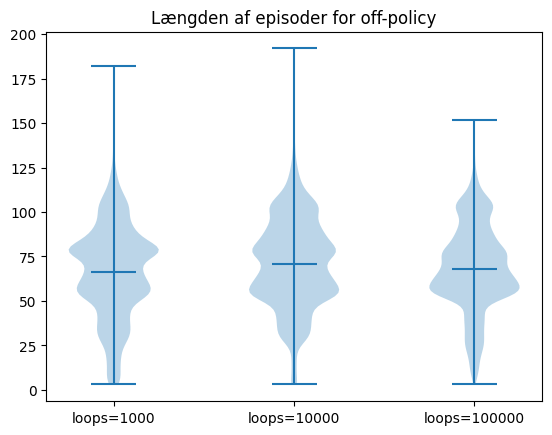

loops=1000: Min:3.0, 0.25:51.0, Median: 68.0, Mean: 66.2321, 0.75:83.0, Max: 182.0, Var: 694.15382959
loops=10000: Min:3.0, 0.25:54.0, Median: 70.0, Mean: 70.8037, 0.75:88.0, Max: 192.0, Var: 630.0131663100001
loops=100000: Min:3.0, 0.25:54.0, Median: 67.0, Mean: 68.0498, 0.75:84.0, Max: 152.0, Var: 580.39471996


In [ ]:
printHistBox((2,2), resultNOffPolicy, "Længden af episoder for off-policy")

In [ ]:
result100000 = {
    "ES": FirstVisitMCControlES(100_000, 2, [-1, 0, 1], [0, -1, 1], genWCol((3,4), 1), b7),
    "Soft": OnPolicyEpsilonSoft(100_000, 2, [-1, 0, 1], [0, -1, 1], 0.1, genWCol((3,4), 1), b7),
    "Off": OffPolicyMCControl(100_000, 2, [-1, 0, 1], [0, -1, 1], genWCol((3,4), 1), b7),
}

Starting First Visit Value Exploring Starts Estimation. ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1], MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten through 85.00%
Gotten through 90.00%
Gotten through 95.00%
Done simulating.
Starting First Visit Value Estimation with ACTIONS: [-1, 0, 1], EVENTS: [0, -1, 1] and MEMORY: 2
Gotten through 5.00%
Gotten through 10.00%
Gotten through 15.00%
Gotten through 20.00%
Gotten through 25.00%
Gotten through 30.00%
Gotten through 35.00%
Gotten through 40.00%
Gotten through 45.00%
Gotten through 50.00%
Gotten through 55.00%
Gotten through 60.00%
Gotten through 65.00%
Gotten through 70.00%
Gotten through 75.00%
Gotten through 80.00%
Gotten thro

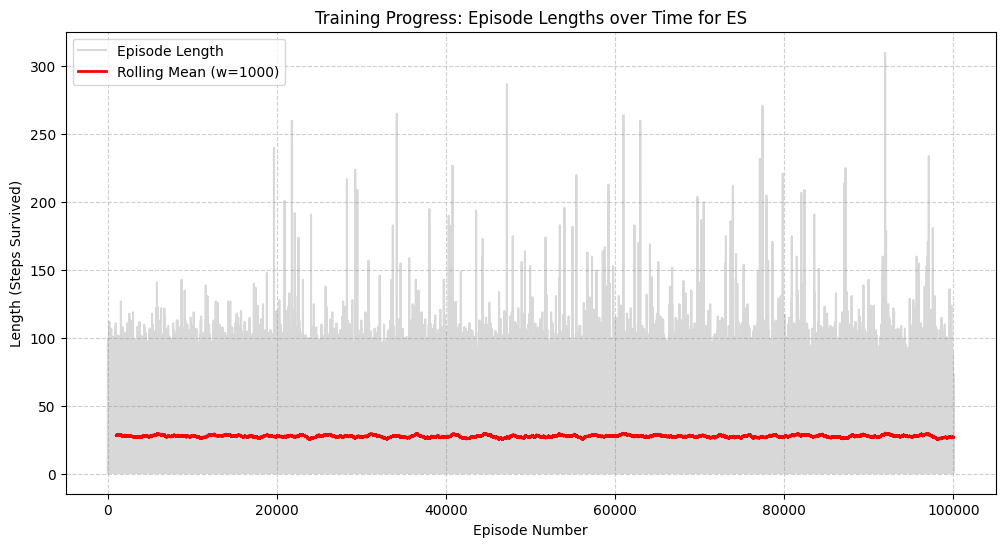

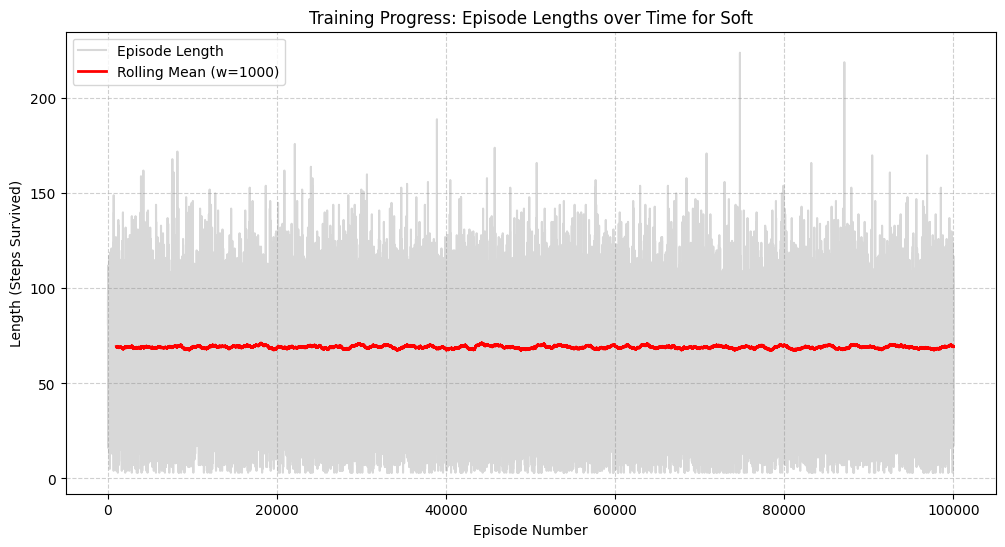

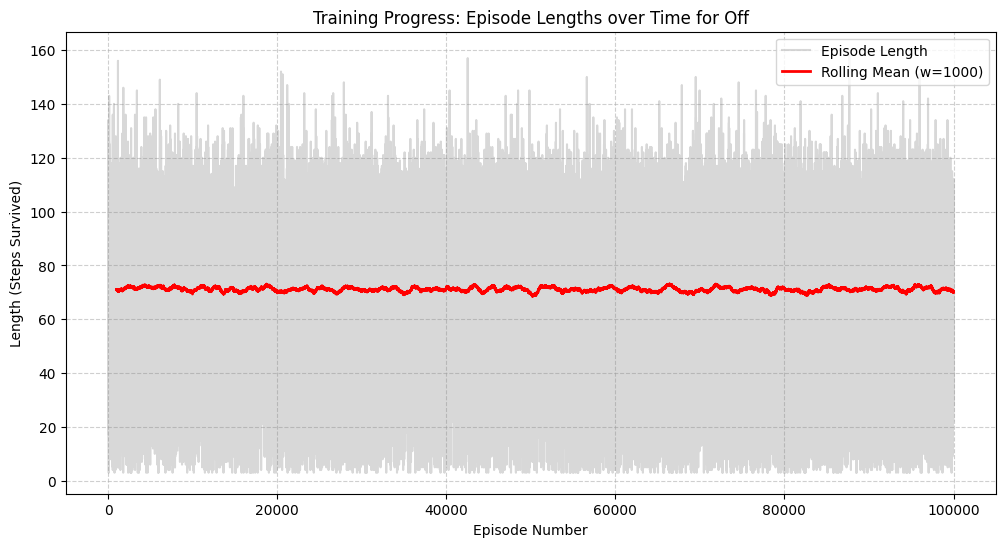

In [ ]:
def plot_progress(lengths, title, window=100):
    plt.figure(figsize=(12, 6))
    plt.plot(lengths, alpha=0.3, label='Episode Length', color='gray')

    # rolling average
    rolling_mean = np.convolve(lengths, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(lengths)), rolling_mean, label=f'Rolling Mean (w={window})', color='red', linewidth=2)

    plt.title('Training Progress: Episode Lengths over Time for ' + key)
    plt.xlabel('Episode Number')
    plt.ylabel('Length (Steps Survived)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


for key, value in result100000.items():
    plot_progress(value["Lengths"], key, 1000)